In [1]:
from collections import Counter, defaultdict
from functools import partial
from multiprocessing import Pool
from pathlib import Path
from pickle import dump, load
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from scipy.stats import pearsonr, spearmanrho
from sklearn.linear_model import (
    LogisticRegressionCV,
)
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_val_predict,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample


In [2]:
project_dir = Path("/path/to/vep_comparisons/")
data_dir = Path("/path/to/vep_comparisons/variants")

variants_path = data_dir / "collated_variants.annotated.tsv.gz"

scores_dir = project_dir / "scoring"

flat_score_paths = {
    "esmc": scores_dir / "collated_variants.esmc_600m.tsv.gz",
    "saprot": scores_dir / "collated_variants.saprot_650m.tsv.gz",
    "nt_100": scores_dir / "ntv3_100m_pre_8192_centered" / "all_shards.tsv.gz",
    "nt_650": scores_dir / "ntv3_650m_pre_8192_centered" / "all_shards.tsv.gz",
    "orthrus": scores_dir / "orthrus_mlm_6_track" / "all_shards.tsv.gz",
}

# Evo2 scores present as sharded parquet files in different directories
# for different variant datasets.
evo_dir = Path("/path/to/evo2-clinvar/results/scores_export/")
evo_score_globs = {
    "finucane_v50": "scores_chunk*",
    "multisusie": "scores_chunk*",
    "eqtl": "scores_chunk*",
    "clinvar": "scores_relabeled.parquet",
}

# RiNaLMo scores present as separate parquet files per dataset.
rinalmo_dir = Path("/path/to/rinalmo-evaluation/results/annotated/")
rinalmo_files = [
    "clinvar_annotated.parquet",
    "gwas_annotated.parquet",
    "eqtl_annotated.parquet",
]

dataset_labels = {
    # "ukbb": ["high_pip"],
    # "multisusie": ["high_pip"],
    "gwas": ["high_pip"],
    "eqtl": ["high_pip"],
    "clinvar": ["Pathogenic", "Likely_pathogenic"],
}

dataset_names: dict[str, str] = {"gwas": "GWAS", "eqtl": "eQTL", "clinvar": "ClinVar"}

annot_names = {
    "gnocchi_z": "Gnocchi",
    "phylop": "PhyloP",
    # "roulette_mr": "Roulette MR",
    "log_roulette_mr": "log(Roulette MR)",
    "gnomadg_af_log": "log(MAF)",
}

model_names = {
    "evo_score": "Evo2",
    "nt_100_score": "NTv3 (100M)",
    "nt_650_score": "NTv3 (650M)",
    "rinalmo_score": "RiNALMo",
    "orthrus_score": "Orthrus",
    "esmc_score": "ESM-C",
    "saprot_score": "SaProt",
}

models_by_modality = {
    "DNA": ["Evo2", "NTv3 (100M)", "NTv3 (650M)"],
    "RNA": ["RiNALMo", "Orthrus"],
    "Protein": ["ESM-C", "SaProt"],
}
model_to_modality = {
    name: modality for modality, models in models_by_modality.items() for name in models
}

pretty_names = {}
pretty_names.update(annot_names)
pretty_names.update(model_names)

In [3]:
_ = pl.Config.set_tbl_rows(15)

## Load all data

Load and merge the following:
- Variants w/ annotations (PhyloP, Gnocchi, Roulette)
    - Create merged "GWAS" group that combines UKBB/Finucane and MultiSuSiE
- Model scores for variant positions
    - Protein models (protein-coding missense variants only)
        - ESM-C 300M
        - SaProt
    - RNA models
        - RiNALMo
        - Orthrus (6-track with MLM objective)
    - DNA models
        - Evo2 7B: p(ref), p(alt), log-likelihood ratio. Both averaged over forward and reverse direction
        - Nucleotide Transformer V3 (100M and 650M)

In [4]:
# Load variants w/ annotations
df = (
    pl.read_csv(
        variants_path,
        separator="\t",
        null_values="-",
        schema_overrides={
            "multisusie_pip": pl.Float64,
            "eqtl_pip": pl.Float64,
        },
    )
    # Remove 1bp deletions and splice site variants in introns
    .filter(
        pl.col("alt") != ".",
        pl.col("cdna_position").is_not_null(),
    )
    .with_columns(
        gnomadg_af_log=(
            pl.when(pl.col("gnomadg_af") == 0)
            .then(None)
            .otherwise(pl.col("gnomadg_af").log10())
        ),
        log_roulette_mr=pl.col("roulette_mr").log10(),
        gwas_pip=pl.max_horizontal(pl.col("ukbb_pip", "multisusie_pip")),
    )
    .with_columns(
        gwas_label=(
            pl.when(pl.col("gwas_pip") >= 0.5)
            .then(pl.lit("high_pip"))
            .otherwise(
                pl.when(pl.col("gwas_pip").is_null())
                .then(None)
                .otherwise(pl.lit("low_pip"))
            )
        )
    )
)

print(df.shape)
df.head()

(333420, 42)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip"""
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip"""
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip"""
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip"""
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip"""


In [5]:
# Filter out variants that are only coming from UKBB and associated with
# non-disease-implicated traits
data_dir = Path("/path/to/vep_comparisons/variants")
ukbb_dir = data_dir / "ukbb_finucane"

ukbb_want_traits = pl.read_csv(
    ukbb_dir / "UKBB_94traits_release1.traits.filtered",
    separator="\t",
)

shared_cols_int = [
    "start",
    "end",
    "cdna_position",
    "cds_position",
    "protein_position",
]
float_cols = [
    "gnomade_af",
    "gnomadg_af",
    "max_af",
]

ukbb_variants = pl.read_csv(
    ukbb_dir / "final_UKBB_94traits_release1.hg38.selected_transcript.txt.gz",
    separator="\t",
    null_values="-",
    schema_overrides={
        **{name: pl.Float64 for name in float_cols},
    },
)

len_before = len(ukbb_variants)
ukbb_variants = ukbb_variants.filter(
    pl.col("trait").is_in(ukbb_want_traits.get_column("trait").to_list())
)
print(f"{len_before} -> {len(ukbb_variants)}")

len_before = len(df)
df = df.with_columns(
    ukbb_only=pl.col("ukbb_label").is_not_null()
    & pl.all_horizontal(
        pl.col("multisusie_label", "eqtl_label", "clinvar_label").is_null()
    ),
    remove_ukbb=~pl.col("variant").is_in(ukbb_variants.get_column("variant").to_list()),
).filter(
    # Remove variants that are only present in UKB dataset and are not in the set of filtered variants
    ~(pl.col("remove_ukbb") & pl.col("ukbb_only"))
)
print(f"{len_before} -> {len(df)}")

123270 -> 118129
333420 -> 329585


In [6]:
def load_score_file(
    path: Path,
    name: str,
    negate_score: bool = True,
) -> pl.DataFrame:
    scores = pl.read_csv(
        path,
        separator="\t",
        columns=("variant", "gene", "feature", "score"),
    )

    if negate_score:
        # Some original scores are log(alt) - log(ref), so negate
        # so we have "pathogenicity" scores, i.e. a score that's
        # high when the alt allele is very low probability
        scores = scores.with_columns(score=-pl.col("score"))

    print(f"{name}: {len(scores)}")
    return scores.rename({"score": f"{name}_score"})


flat_scores = {
    name: load_score_file(path, name, negate_score=True)
    for name, path in flat_score_paths.items()
}

esmc: 48491
saprot: 38290
nt_100: 340299
nt_650: 340299
orthrus: 333420


In [7]:
def load_one_rinalmo(path: Path) -> pl.DataFrame:
    return (
        pl.read_parquet(
            path,
            columns=[
                "chrom",
                "pos",
                "ref",
                "alt",
                "transcript_id",
                "gene_id",
                "score_ref",
                "score_alt",
            ],
        )
        .with_columns(
            variant=pl.format("chr{}:{}:{}:{}", "chrom", "pos", "ref", "alt"),
            gene=pl.col("gene_id").str.split(".").list[0],
            feature=pl.col("transcript_id").str.split(".").list[0],
            # Do log p(alt) - log p(ref) to have a "pathogenicity" score
            rinalmo_score=pl.col("score_ref") - pl.col("score_alt"),
        )
        .drop(
            "chrom",
            "pos",
            "ref",
            "alt",
            "gene_id",
            "transcript_id",
            "score_ref",
            "score_alt",
        )
    )


all_rinalmo_scores = pl.concat(
    [load_one_rinalmo(rinalmo_dir / filename) for filename in rinalmo_files]
).unique("variant")
all_rinalmo_scores.shape

(404803, 4)

In [8]:
def load_one_evo(path: Path, glob: str) -> pl.DataFrame:
    evo_scores = (
        pl.concat([pl.read_parquet(path) for path in sorted(path.glob(glob))])
        .with_columns(chrom=pl.col("chrom").cast(pl.String))
        .with_columns(
            chrom=pl.when(pl.col("chrom").str.contains("chr"))
            .then(pl.col("chrom"))
            .otherwise(pl.format("chr{}", "chrom")),
            evo_ref_prob=pl.mean_horizontal(
                pl.col("score_ref_fwd").exp(), pl.col("score_ref_rev").exp()
            ),
            evo_alt_prob=pl.mean_horizontal(
                pl.col("score_alt_fwd").exp(), pl.col("score_alt_rev").exp()
            ),
        )
        .with_columns(
            variant=pl.format("{}:{}:{}:{}", "chrom", "pos", "ref", "alt"),
            evo_score=pl.col("evo_ref_prob").log() - pl.col("evo_alt_prob").log(),
        )
        .select(
            "variant",
            "evo_ref_prob",
            "evo_alt_prob",
            "evo_score",
        )
    )
    return evo_scores


all_evo_scores = pl.concat(
    [load_one_evo(evo_dir / name, glob) for (name, glob) in evo_score_globs.items()],
    how="diagonal",
).unique("variant")
all_evo_scores.shape

(469215, 4)

In [9]:
def merge_and_report(
    df: pl.DataFrame,
    oth: pl.DataFrame,
    on: list[str],
    name: str,
) -> pl.DataFrame:
    merged = df.join(oth, on=on, how="left")
    present = merged.get_column(f"{name}_score").is_not_null().sum()
    print(f"{name}: {len(oth)} -> {present} merged")
    return merged


flat_scores.update(
    {
        "evo": all_evo_scores,
        "rinalmo": all_rinalmo_scores,
    }
)

for name, vals in flat_scores.items():
    cols = ["variant"] if name == "evo" else ["variant", "gene", "feature"]
    df = merge_and_report(df, vals, on=cols, name=name)

print(df.shape)
df.head()

esmc: 48491 -> 48149 merged
saprot: 38290 -> 38017 merged
nt_100: 340299 -> 329585 merged
nt_650: 340299 -> 329585 merged
orthrus: 333420 -> 329585 merged
evo: 469215 -> 315327 merged
rinalmo: 404803 -> 227881 merged
(329585, 53)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,ukbb_only,remove_ukbb,esmc_score,saprot_score,nt_100_score,nt_650_score,orthrus_score,evo_ref_prob,evo_alt_prob,evo_score,rinalmo_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip""",true,false,null,null,-1.512764,-1.637647,-0.138533,0.314054,0.314115,-0.000196,-1.25
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip""",true,false,null,null,-0.702198,-0.67272,0.84236,0.336628,0.33667,-0.000124,-0.375
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip""",true,false,null,null,1.423264,1.435684,0.052534,0.329573,0.329497,0.000231,1.25
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip""",true,false,null,null,1.492862,1.665321,0.893877,0.318683,0.318626,0.000177,null
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip""",true,false,null,null,0.018063,-0.407629,-0.602901,0.306684,0.306683,0.000003,null


### Variant counts

In [10]:
(
    df.with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys())
    .unpivot(variable_name="dataset", value_name="label")
    .pivot(on="dataset", values="dataset", aggregate_function="len")
    .filter(pl.col("label").is_not_null())
)

label,gwas,eqtl,clinvar
str,u32,u32,u32
"""neg""",121112,67072,142426
"""pos""",1702,10961,23056


In [11]:
df.head()

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,ukbb_only,remove_ukbb,esmc_score,saprot_score,nt_100_score,nt_650_score,orthrus_score,evo_ref_prob,evo_alt_prob,evo_score,rinalmo_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip""",true,false,null,null,-1.512764,-1.637647,-0.138533,0.314054,0.314115,-0.000196,-1.25
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip""",true,false,null,null,-0.702198,-0.67272,0.84236,0.336628,0.33667,-0.000124,-0.375
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip""",true,false,null,null,1.423264,1.435684,0.052534,0.329573,0.329497,0.000231,1.25
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip""",true,false,null,null,1.492862,1.665321,0.893877,0.318683,0.318626,0.000177,null
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip""",true,false,null,null,0.018063,-0.407629,-0.602901,0.306684,0.306683,0.000003,null


In [12]:
(
    df.unique("variant")
    .with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys(), "gnomadg_af")
    .unpivot(index="gnomadg_af", variable_name="dataset", value_name="label")
    .filter(pl.col("label").is_not_null())
    .group_by(pl.col("dataset", "label"))
    .agg(N=pl.col("gnomadg_af").len(), maf=pl.col("gnomadg_af").median())
    .sort(by=["dataset", "label"])
    # .pivot(
    #     on=pl.col("dataset", "label"),
    #     index=pl.col("dataset", "label"),
    #     aggregate_function="len",
    # )
    # .pivot(on="label", values="label", aggregate_function="len")
    # .filter(pl.col("label").is_not_null())
    # .transpose(include_header=True)
)

dataset,label,N,maf
str,str,u32,f64
"""clinvar""","""neg""",140353,0.000486
"""clinvar""","""pos""",22796,0.000013
"""eqtl""","""neg""",66229,0.2536
"""eqtl""","""pos""",10817,0.2666
"""gwas""","""neg""",118213,0.18745
"""gwas""","""pos""",1655,0.08323


## Correlations

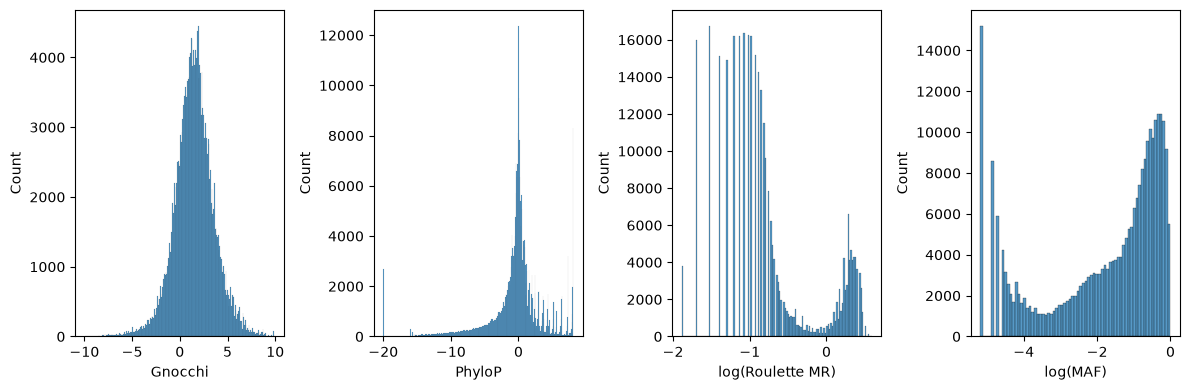

In [13]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(annot_names),
    sharey=False,
    sharex=False,
    figsize=(12, 4),
)
for (annot, name), ax in zip(annot_names.items(), axs):
    sns.histplot(x=df.get_column(annot).drop_nulls(), ax=ax)
    ax.set_xlabel(name)
plt.tight_layout()

In [14]:
hist_color = "#3C6E71"
fit_color = "#D1495B"


def corr_model_vs_annotations(
    data: pl.DataFrame,
    model_col: str,
    annotations: dict[str, str] = annot_names,
    model_name: str | None = None,
    clip: bool = True,
) -> pl.dataframe:
    if model_name is None:
        model_name = model_col

    fig, axs = plt.subplots(
        nrows=1,
        ncols=len(annotations),
        sharex=False,
        figsize=(10, 4),
    )
    sns.despine(fig)

    if clip:
        scores = data.get_column(model_col).drop_nulls().to_numpy()
        ymin, ymax = np.quantile(scores, q=(0.001, 0.999))

    corr_data = []
    for i, ((annot, name), ax) in enumerate(zip(annotations.items(), axs)):
        plot_data = data.filter(
            pl.col(model_col).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        x_vals = plot_data.get_column(annot).to_numpy()
        y_vals = plot_data.get_column(model_col).to_numpy()
        r = pearsonr(x_vals, y_vals)
        rho = spearmanrho(x_vals, y_vals)

        sns.regplot(
            x=plot_data.get_column(annot),
            y=plot_data.get_column(model_col),
            marker=".",
            line_kws={"color": fit_color, "alpha": 0.7},
            ax=ax,
            scatter=False,
        )
        sns.histplot(
            x=plot_data.get_column(annot),
            y=plot_data.get_column(model_col),
            alpha=1,
            color=hist_color,
            ax=ax,
        )
        ax.set_xlabel(name)
        ax.text(
            0.95,
            0.95,
            s=(
                f"r={r.statistic:0.2f}"
                "\n"
                rf"$\rho$={rho.statistic:0.2f}"
            ),
            transform=ax.transAxes,
            ha="right",
            va="top",
        )
        if i == 0:
            ax.set_ylabel(model_name)
        else:
            ax.set_ylabel(None)
        if clip:
            ax.set_ylim(ymin, ymax)
        corr_data.append(
            {
                "model_name": model_name,
                "name": name,
                "pearson": r.statistic,
                "spearman": rho.statistic,
            }
        )

    plt.tight_layout()
    return pl.DataFrame(corr_data)

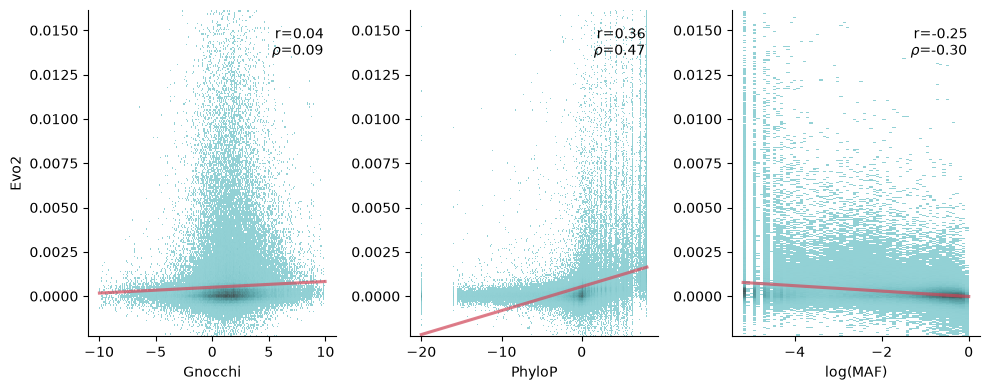

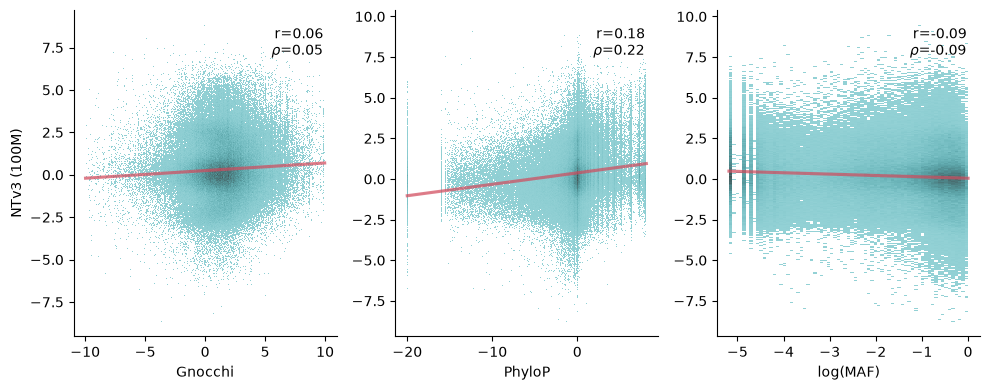

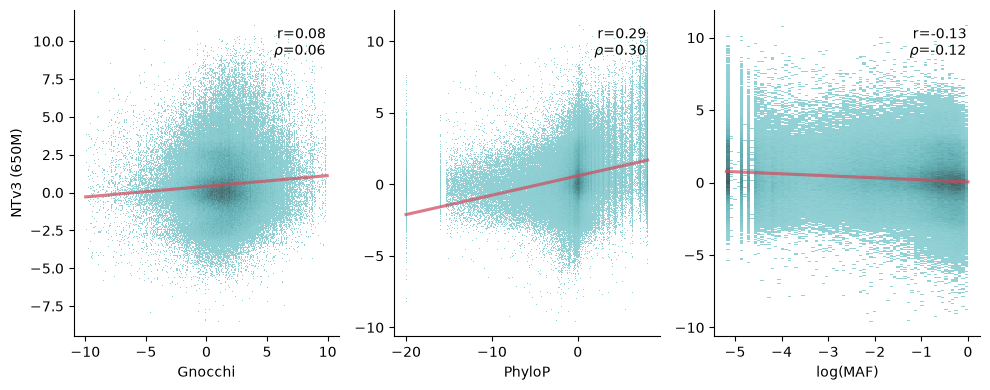

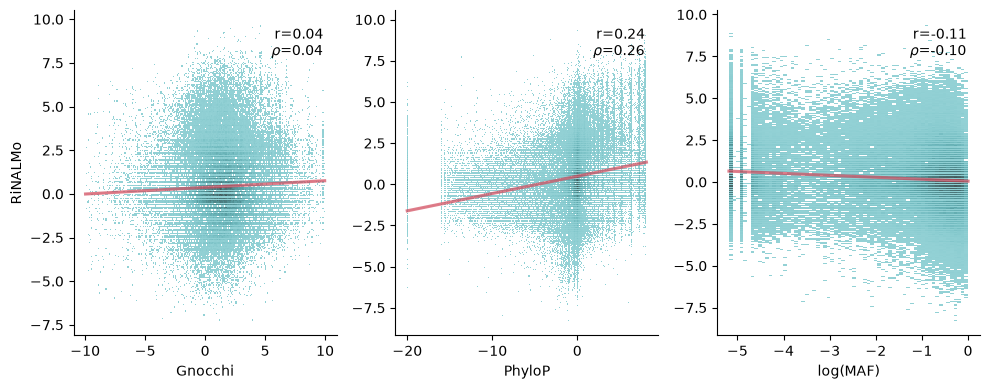

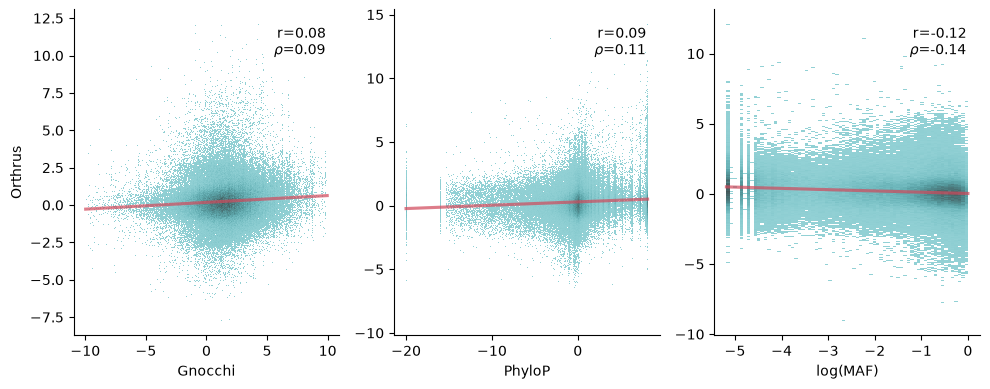

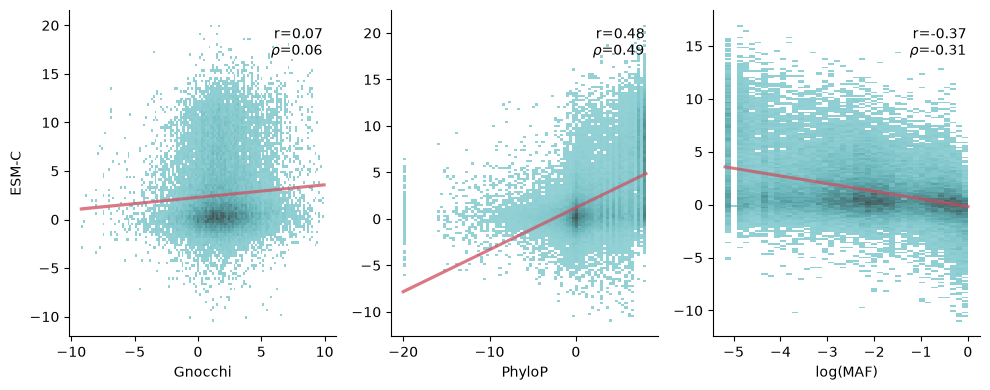

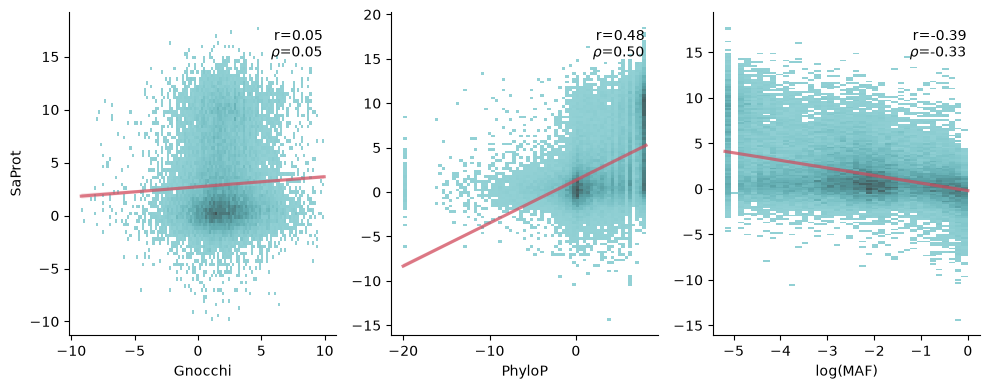

In [15]:
want_annots = {k: v for k, v in annot_names.items() if "roulette" not in k}

all_corrs = []
for score_name, pretty_name in model_names.items():
    all_corrs.append(
        corr_model_vs_annotations(
            data=df,
            model_col=score_name,
            model_name=pretty_name,
            clip=score_name == "evo_score",
            annotations=want_annots,
        )
    )
    plt.show()

all_corrs = pl.concat(all_corrs)

In [16]:
(
    all_corrs.filter(pl.col("model_name") != "NTv3 (100M)")
    .group_by("name")
    .agg(
        pearson=pl.col("pearson").median(),
        spearman=pl.col("spearman").median(),
    )
)

name,pearson,spearman
str,f64,f64
"""log(MAF)""",-0.191074,-0.222937
"""PhyloP""",0.32302,0.386258
"""Gnocchi""",0.059161,0.061649


329585 -> 186856


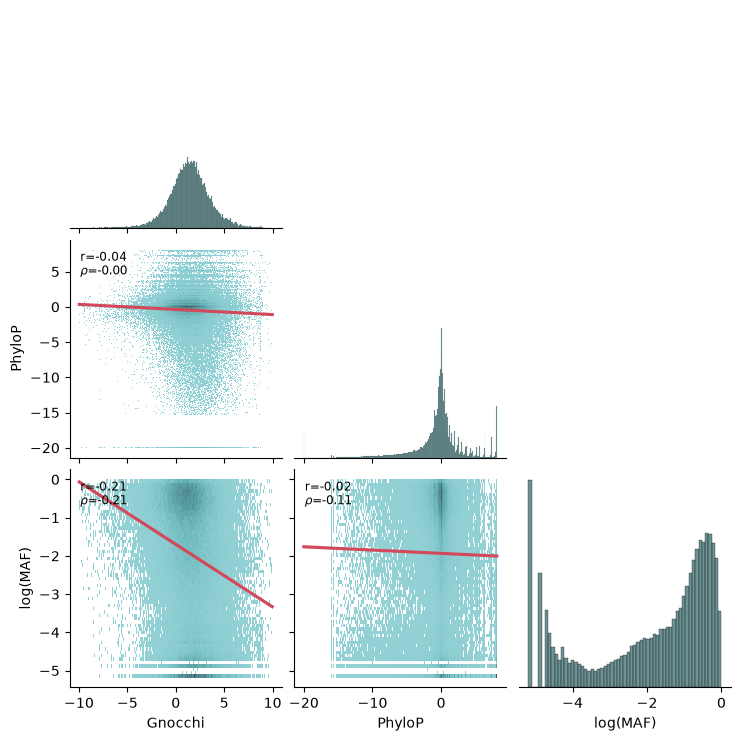

In [17]:
plot_data = df.filter(
    pl.all_horizontal(pl.col(*annot_names.keys()).is_not_null())
).select([k for k in annot_names if "roulette" not in k])
print(f"{len(df)} -> {len(plot_data)}")

g = sns.pairplot(
    plot_data.to_pandas(),
    corner=True,
    markers=".",
    kind="hist",
    diag_kws={"color": hist_color},
    plot_kws={"color": hist_color},
)
g.map_lower(sns.regplot, scatter=False, color=fit_color)

for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if ax is None:
            continue

        xvar = ax.get_xlabel()
        yvar = ax.get_ylabel()
        if xvar == "" or yvar == "":
            continue

        xvals = plot_data.get_column(xvar).to_numpy()
        yvals = plot_data.get_column(yvar).to_numpy()

        r = pearsonr(xvals, yvals)
        rho = spearmanrho(xvals, yvals)
        ax.text(
            0.05,
            0.95,
            s=(
                f"r={r.statistic:0.2f}"
                "\n"
                rf"$\rho$={rho.statistic:0.2f}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            size="small",
        )

        if i == len(annot_names) - 2:
            ax.set_xlabel(annot_names[xvar])
        if j == 0:
            ax.set_ylabel(annot_names[yvar])

last = g.axes[-1][-1]
last.set_xlabel(annot_names[last.get_xlabel()])
g.tight_layout()


### eQTLs for GWAS hits

In [19]:
(
    df.with_columns(eqtl_label=pl.format("eqtl_{}", "eqtl_label")).pivot(
        on="eqtl_label",
        index="gwas_label",
        values="eqtl_label",
        aggregate_function="len",
    )
)

gwas_label,null,eqtl_low_pip,eqtl_high_pip
str,u32,u32,u32
"""low_pip""",99809,22437,3117
"""high_pip""",1522,47,165
null,160756,44828,7826


In [20]:
(df.filter(pl.col("ukbb_label").is_null(), pl.col("multisusie_label").is_null()).head())

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,evo_ref_prob,evo_alt_prob,evo_score,rinalmo_score,esmc_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64
"""chr1:135203:G:A""","""ENSG00000308579""","""chr1""","""G""","""A""","""ENST00000835176""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADg_AMI""",135202,135203,508,null,null,0.06026,0.04113,0.09773,null,null,null,null,0.9994909,"""high_pip""","""ENSG00000308579""",0.939095,"""Whole_Blood""","""Lung,Spleen,Testis,Whole_Blood""",null,null,null,null,0.096,null,1.966,null,"""low""",-1.385841,0.293584,null,null,0.559292,0.559184,0.000192,null,null
"""chr1:263722:C:G""","""ENSG00000292994""","""chr1""","""C""","""G""","""ENST00000424587""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADg_AFR""",263721,263722,4896,null,null,0.125,0.2196,0.4322,null,null,null,null,0.9999956,"""high_pip""","""ENSG00000292994""",0.708986,"""Thyroid""","""Thyroid""",null,null,null,null,-0.152,null,0.051,null,"""low""",-0.658368,-1.29243,null,null,0.366771,0.366496,0.000749,0.125,null
"""chr1:267812:C:T""","""ENSG00000292994""","""chr1""","""C""","""T""","""ENST00000424587""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADg_SAS""",267811,267812,806,null,null,null,0.02357,0.05624,null,null,null,null,0.9635084,"""high_pip""","""ENSG00000292994""",-2.532786,"""Adipose_Subcutaneous""","""Adipose_Subcutaneous,Brain_Amy…",null,null,null,null,0.421,null,1.897,null,"""low""",-1.62764,0.278067,null,null,0.351818,0.351894,-0.000214,-2.875,null
"""chr1:267879:G:C""","""ENSG00000292994""","""chr1""","""G""","""C""","""ENST00000424587""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADg_AFR""",267878,267879,739,null,null,null,0.03144,0.09231,null,null,null,null,0.069417,"""low_pip""","""ENSG00000292994""",null,"""Brain_Spinal_cord_cervical_c-1""","""Brain_Spinal_cord_cervical_c-1""",null,null,null,null,0.428,null,0.02,null,"""low""",-1.502517,-1.69897,null,null,0.350959,0.35081,0.000424,-0.25,null
"""chr1:502653:G:T""","""ENSG00000290385""","""chr1""","""G""","""T""","""ENST00000641063""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADe_AFR""",502652,502653,268,null,null,0.02113,0.08702,0.5,null,null,null,null,0.5897274,"""high_pip""","""ENSG00000290385""",-0.774438,"""Whole_Blood""","""Whole_Blood""",null,null,null,null,0.096,null,0.03,null,"""low""",-1.060381,-1.522879,null,null,0.475459,0.474631,0.001741,null,null


In [21]:
gwas_data = df.filter(pl.col("gwas_label").is_not_null())
gwas_eqtl_data = gwas_data.filter(pl.col("eqtl_label").is_not_null())
print(f"{len(gwas_data)} -> {len(gwas_eqtl_data)}")

127097 -> 25766


In [22]:
roc_auc_score(
    y_true=(gwas_eqtl_data.get_column("gwas_label") == "high_pip").cast(pl.UInt8),
    y_score=gwas_eqtl_data.get_column("eqtl_pip"),
)

0.8548413385786076

### Model classification of binned annotations

In [18]:
flip = ["log_roulette_mr", "gnomadg_af_log"]
results = []
for model, model_name in model_names.items():
    for annot, annot_name in annot_names.items():
        if "roulette" in annot:
            continue
        want_data = df.filter(
            pl.col(model).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        low_thresh, high_thresh = want_data.get_column(annot).quantile([0.25, 0.75])

        high_label = 0 if annot in flip else 1
        low_label = 1 if annot in flip else 0

        labeled_data = want_data.with_columns(
            label=(
                pl.when(pl.col(annot) <= low_thresh)
                .then(low_label)
                .otherwise(
                    pl.when(pl.col(annot) >= high_thresh)
                    .then(high_label)
                    .otherwise(None)
                )
            )
        ).filter(pl.col("label").is_not_null())
        y_true = labeled_data.get_column("label")
        y_score = labeled_data.get_column(model)
        results.append(
            {
                "model": model_name,
                "annotation": annot_name,
                "auroc": roc_auc_score(y_true=y_true, y_score=y_score),
                "auprc": average_precision_score(y_true=y_true, y_score=y_score),
                "num_pos": y_true.sum(),
                "num_neg": len(y_true) - y_true.sum(),
            }
        )
results = pl.DataFrame(results)
results

model,annotation,auroc,auprc,num_pos,num_neg
str,str,f64,f64,i64,i64
"""Evo2""","""Gnocchi""",0.573088,0.555961,53941,53942
"""Evo2""","""PhyloP""",0.838214,0.866503,78848,78830
"""Evo2""","""log(MAF)""",0.709823,0.728732,66010,66004
"""NTv3 (100M)""","""Gnocchi""",0.539454,0.530529,56393,56394
"""NTv3 (100M)""","""PhyloP""",0.658854,0.653588,82407,82391
"""NTv3 (100M)""","""log(MAF)""",0.563736,0.553314,69331,69328
"""NTv3 (650M)""","""Gnocchi""",0.549371,0.551978,56393,56394
"""NTv3 (650M)""","""PhyloP""",0.718373,0.733728,82407,82391
…,…,…,…,…,…


In [19]:
results.filter(pl.col("annotation") == "PhyloP")

model,annotation,auroc,auprc,num_pos,num_neg
str,str,f64,f64,i64,i64
"""Evo2""","""PhyloP""",0.838214,0.866503,78848,78830
"""NTv3 (100M)""","""PhyloP""",0.658854,0.653588,82407,82391
"""NTv3 (650M)""","""PhyloP""",0.718373,0.733728,82407,82391
"""RiNALMo""","""PhyloP""",0.686131,0.698849,56967,56973
"""Orthrus""","""PhyloP""",0.577727,0.564746,82407,82391
"""ESM-C""","""PhyloP""",0.862592,0.884851,12037,12042
"""SaProt""","""PhyloP""",0.865034,0.880215,9507,9507


In [20]:
(
    results.filter(pl.col("model") != "NTv3 (100M)")
    .group_by("annotation")
    .agg(
        auroc=pl.col("auroc").median(),
        auprc=pl.col("auprc").median(),
    )
)

annotation,auroc,auprc
str,f64,f64
"""PhyloP""",0.778294,0.800116
"""Gnocchi""",0.546667,0.549761
"""log(MAF)""",0.658735,0.659166


In [21]:
# Shared sites only
flip = ["log_roulette_mr", "gnomadg_af_log"]
results = []

shared_data = df.filter(pl.all_horizontal(pl.col(*model_names.keys())).is_not_null())

for model, model_name in model_names.items():
    for annot, annot_name in annot_names.items():
        if "roulette" in annot:
            continue
        want_data = shared_data.filter(
            pl.col(model).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        low_thresh, high_thresh = want_data.get_column(annot).quantile([0.25, 0.75])

        high_label = 0 if annot in flip else 1
        low_label = 1 if annot in flip else 0

        labeled_data = want_data.with_columns(
            label=(
                pl.when(pl.col(annot) <= low_thresh)
                .then(low_label)
                .otherwise(
                    pl.when(pl.col(annot) >= high_thresh)
                    .then(high_label)
                    .otherwise(None)
                )
            )
        ).filter(pl.col("label").is_not_null())
        y_true = labeled_data.get_column("label")
        y_score = labeled_data.get_column(model)
        results.append(
            {
                "model": model_name,
                "annotation": annot_name,
                "auroc": roc_auc_score(y_true=y_true, y_score=y_score),
                "auprc": average_precision_score(y_true=y_true, y_score=y_score),
                "num_pos": y_true.sum(),
                "num_neg": len(y_true) - y_true.sum(),
            }
        )
results = pl.DataFrame(results)
results

model,annotation,auroc,auprc,num_pos,num_neg
str,str,f64,f64,i64,i64
"""Evo2""","""Gnocchi""",0.578955,0.543917,6196,6196
"""Evo2""","""PhyloP""",0.955014,0.948036,8816,8819
"""Evo2""","""log(MAF)""",0.810849,0.803353,7357,7357
"""NTv3 (100M)""","""Gnocchi""",0.531739,0.543273,6206,6207
"""NTv3 (100M)""","""PhyloP""",0.5718,0.602805,8830,8835
"""NTv3 (100M)""","""log(MAF)""",0.488106,0.51556,7372,7374
"""NTv3 (650M)""","""Gnocchi""",0.568294,0.580345,6206,6207
"""NTv3 (650M)""","""PhyloP""",0.758174,0.805481,8830,8835
…,…,…,…,…,…


In [22]:
(
    results.filter(pl.col("model") != "NTv3 (100M)")
    .group_by("annotation")
    .agg(
        auroc=pl.col("auroc").median(),
        auprc=pl.col("auprc").median(),
    )
)

annotation,auroc,auprc
str,f64,f64
"""log(MAF)""",0.671526,0.706038
"""Gnocchi""",0.540871,0.547452
"""PhyloP""",0.812474,0.844229


## Data distributions

In [18]:
def melt_scores(df: pl.DataFrame, name: str) -> pl.DataFrame:
    return (
        df.unpivot(
            on=["phylop", "gnomadg_af_log", "gnocchi_z"],
            index="variant",
        )
        .with_columns(dataset=pl.lit(name))
        .filter(pl.col("value").is_not_null())
    )


plot_data = pl.concat(
    (
        melt_scores(
            df.filter(
                pl.col("gwas_label").is_not_null(), pl.col("gwas_label") == "high_pip"
            ),
            "GWAS",
        ),
        melt_scores(
            df.filter(
                pl.col("eqtl_label").is_not_null(), pl.col("eqtl_label") == "high_pip"
            ),
            "eQTL",
        ),
        melt_scores(
            df.filter(
                pl.col("clinvar_label").is_not_null(),
                pl.col("clinvar_label").str.contains("athogenic"),
            ),
            "ClinVar",
        ),
    )
)
plot_data.head()

variant,variable,value,dataset
str,str,f64,str
"""chr1:1204482:T:C""","""phylop""",-3.715,"""GWAS"""
"""chr1:2512975:G:A""","""phylop""",2.808,"""GWAS"""
"""chr1:3473193:A:G""","""phylop""",6.807,"""GWAS"""
"""chr1:3774964:A:G""","""phylop""",-0.515,"""GWAS"""
"""chr1:6236178:T:G""","""phylop""",-2.971,"""GWAS"""


<Axes: xlabel='value', ylabel='Density'>

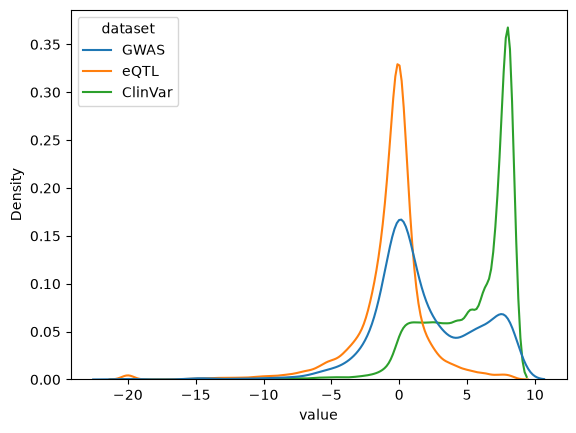

In [11]:
sns.kdeplot(
    x="value",
    hue="dataset",
    data=plot_data.filter(pl.col("variable") == "phylop"),
    common_norm=False,
)

<Axes: xlabel='value', ylabel='Proportion'>

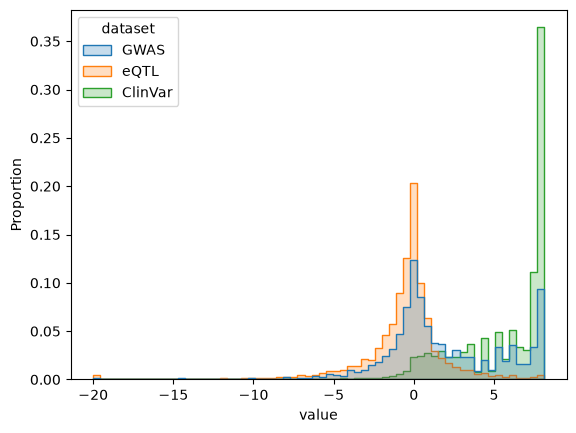

In [12]:
sns.histplot(
    x="value",
    hue="dataset",
    common_norm=False,
    stat="proportion",
    # fill=False,
    element="step",
    data=plot_data.filter(pl.col("variable") == "phylop"),
)

Text(0.5, 0, 'log(MAF)')

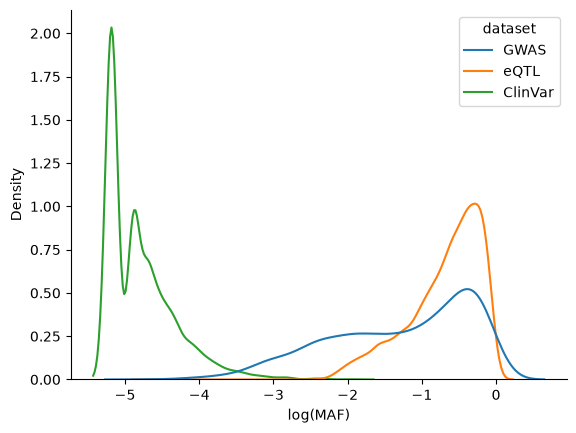

In [13]:
sns.kdeplot(
    x="value",
    hue="dataset",
    common_norm=False,
    data=plot_data.filter(pl.col("variable") == "gnomadg_af_log"),
)
sns.despine()
plt.xlabel("log(MAF)")

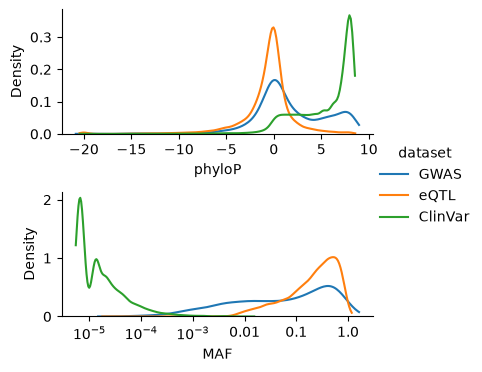

In [41]:
from matplotlib import ticker


def maf_format(x, pos):
    if x < -2:
        return rf"$10^{{{int(x)}}}$"
    return f"{10**x}"


fg = sns.FacetGrid(
    aspect=2,
    height=2,
    row="variable",
    hue="dataset",
    sharex=False,
    sharey=False,
    data=(
        plot_data.filter(
            pl.col("variable").is_in(["phylop", "gnomadg_af_log"])
        ).with_columns(
            variable=pl.col("variable").replace(
                {"phylop": "phyloP", "gnomadg_af_log": "MAF"}
            )
        )
    ),
)
fg.map_dataframe(
    sns.kdeplot,
    x="value",
    common_norm=False,
    legend=True,
    cut=1,
)
for name, ax in fg.axes_dict.items():
    ax.set_xlabel(name)
    ax.set_title("")

    if name == "MAF":
        # locs, labels = ax.get_xticks()
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(maf_format))


fg.add_legend()

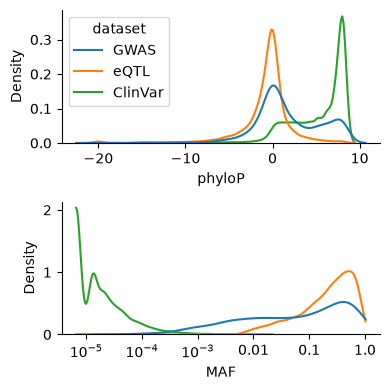

In [53]:
from matplotlib import ticker


def maf_format(x, pos):
    if x < -2:
        return rf"$10^{{{int(x)}}}$"
    return f"{10**x}"


plot_df = plot_data.filter(
    pl.col("variable").is_in(["phylop", "gnomadg_af_log"])
).with_columns(
    variable=pl.col("variable").replace({"phylop": "phyloP", "gnomadg_af_log": "MAF"})
)

variables = ["phyloP", "MAF"]

# Any facet-specific sns.kdeplot arguments can go here
kde_kwargs = {
    "phyloP": {
        # e.g. "bw_adjust": 0.5,
        # e.g. "cut": 3,
    },
    "MAF": {
        "clip": (plot_df.filter(variable="MAF").get_column("value").min(), 0.01),
        # e.g. "bw_adjust": 1,
        # e.g. "cut": 0,
    },
}

fig, axes = plt.subplots(
    nrows=len(variables),
    ncols=1,
    figsize=(4, 2 * len(variables)),
)

for i, (variable, ax) in enumerate(zip(variables, axes)):
    sns.kdeplot(
        data=plot_df.filter(pl.col("variable") == variable),
        x="value",
        hue="dataset",
        common_norm=False,
        legend=i == 0,
        ax=ax,
        **kde_kwargs[variable],
    )

    ax.set_xlabel(variable)
    ax.set_ylabel("Density")
    ax.set_title("")
    sns.despine(ax=ax)

    if variable == "MAF":
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(maf_format))

plt.tight_layout()

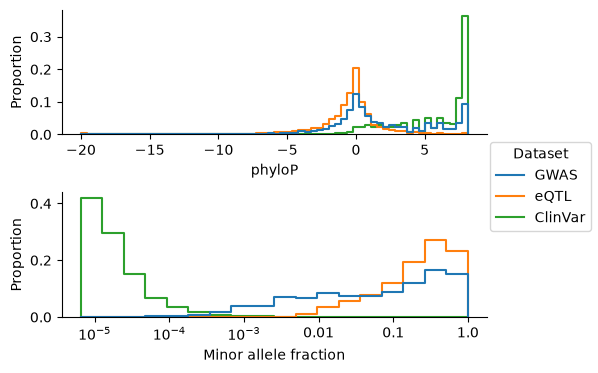

In [58]:
from matplotlib import ticker
from matplotlib.lines import Line2D


def maf_format(x, pos):
    if x < -2:
        return rf"$10^{{{int(x)}}}$"
    return f"{10**x}"


# Explicitly define hue order + colors
hue_order = plot_data["dataset"].unique(maintain_order=True).to_list()
colors = sns.color_palette(n_colors=len(hue_order))
palette = dict(zip(hue_order, colors))


fg = sns.FacetGrid(
    aspect=3,
    height=2,
    row="variable",
    # hue="dataset",
    sharex=False,
    sharey=False,
    data=(
        plot_data.filter(
            pl.col("variable").is_in(["phylop", "gnomadg_af_log"])
        ).with_columns(
            variable=pl.col("variable").replace(
                {"phylop": "phyloP", "gnomadg_af_log": "Minor allele fraction"}
            )
        )
    ),
)
fg.map_dataframe(
    sns.histplot,
    x="value",
    common_norm=False,
    legend=False,
    hue_order=hue_order,
    palette=palette,
    stat="proportion",
    hue="dataset",
    fill=False,
    # alpha=0.1,
    element="step",
)

for name, ax in fg.axes_dict.items():
    ax.set_xlabel(name)
    ax.set_title("")

    if name == "Minor allele fraction":
        # locs, labels = ax.get_xticks()
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(maf_format))

    for line in ax.lines:
        x = np.asarray(line.get_xdata())
        y = np.asarray(line.get_ydata())

        line.set_data(
            np.r_[x[0], x, x[-1]],
            np.r_[0, y, 0],
        )

handles = [
    Line2D(
        [0],
        [0],
        color=palette[name],
        linewidth=1.5,
        label=name,
    )
    for name in hue_order
]

fg.figure.legend(
    handles=handles,
    labels=hue_order,
    title="Dataset",
    loc="center right",
)

# Leave room for the legend
fg.figure.subplots_adjust(right=0.82)

In [47]:
ax.lines

<Axes.ArtistList of 3 lines>

In [ ]:
fg.axes_dict

{'phyloP': <Axes: title={'center': 'variable = phyloP'}, ylabel='Density'>,
 'log(MAF)': <Axes: title={'center': 'variable = log(MAF)'}, xlabel='value', ylabel='Density'>}

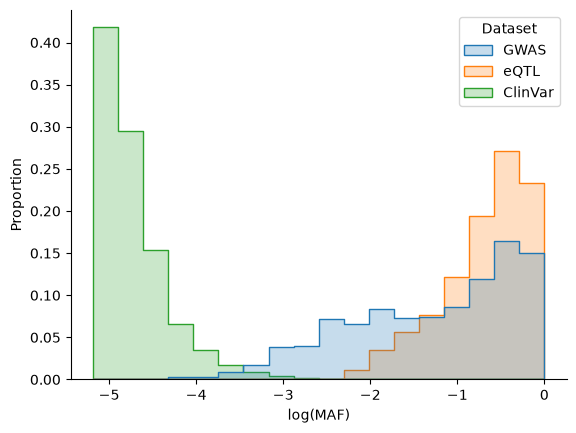

In [ ]:
ax = sns.histplot(
    x="value",
    hue="dataset",
    common_norm=False,
    stat="proportion",
    # fill=False,
    element="step",
    data=plot_data.filter(pl.col("variable") == "gnomadg_af_log"),
)
sns.move_legend(ax, loc="best", title="Dataset")

plt.xlabel("log(MAF)")
sns.despine()

In [ ]:
plot_data

variant,variable,value,dataset
str,str,f64,str
"""chr1:1204482:T:C""","""phylop""",-3.715,"""GWAS"""
"""chr1:2512975:G:A""","""phylop""",2.808,"""GWAS"""
"""chr1:3473193:A:G""","""phylop""",6.807,"""GWAS"""
"""chr1:3774964:A:G""","""phylop""",-0.515,"""GWAS"""
"""chr1:6236178:T:G""","""phylop""",-2.971,"""GWAS"""
"""chr1:7776599:A:C""","""phylop""",-1.802,"""GWAS"""
"""chr1:9181780:G:A""","""phylop""",-1.015,"""GWAS"""
"""chr1:9181780:G:A""","""phylop""",-1.015,"""GWAS"""
…,…,…,…


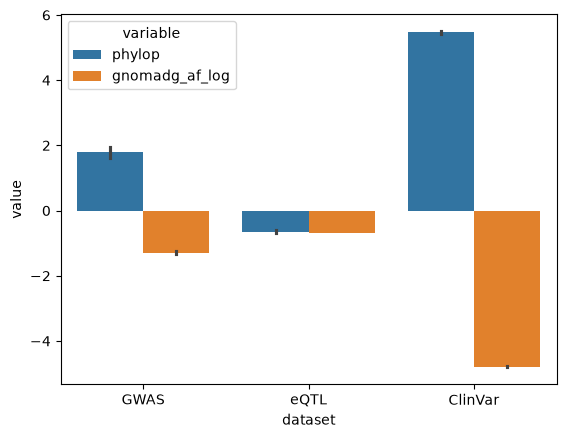

In [ ]:
ax = sns.barplot(
    x="dataset",
    y="value",
    hue="variable",
    data=plot_data.filter(pl.col("variable").is_in(["phylop", "gnomadg_af_log"])),
)

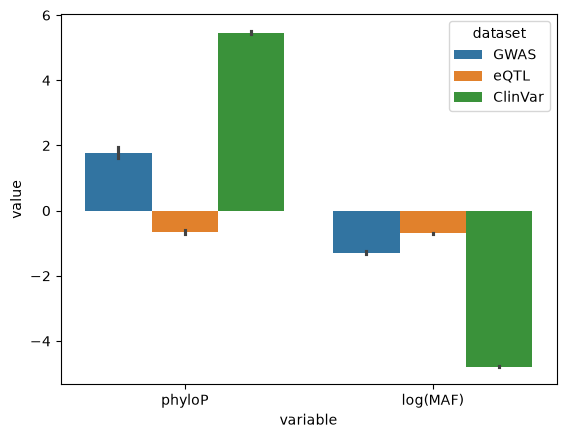

In [ ]:
ax = sns.barplot(
    x="variable",
    y="value",
    hue="dataset",
    data=(
        plot_data.filter(
            pl.col("variable").is_in(["phylop", "gnomadg_af_log"])
        ).with_columns(
            variable=pl.col("variable").replace(
                {"phylop": "phyloP", "gnomadg_af_log": "log(MAF)"}
            )
        )
    ),
)

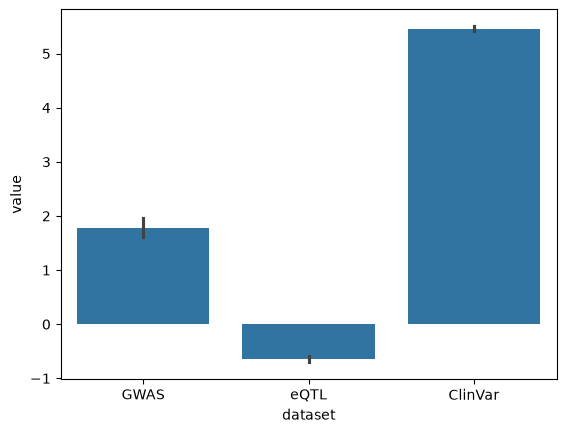

In [ ]:
ax = sns.barplot(
    x="dataset",
    y="value",
    data=plot_data.filter(variable="phylop"),
)

In [ ]:
sns.barplot()

<Axes: xlabel='gnomadg_af_log', ylabel='phylop'>

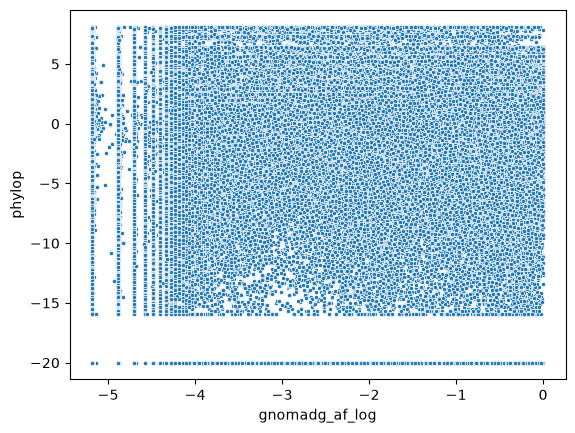

In [25]:
plot_data = df.select("phylop", "gnomadg_af_log").filter(
    pl.all_horizontal(pl.all().is_not_null())
)
sns.scatterplot(x="gnomadg_af_log", y="phylop", data=plot_data, marker=".")

In [26]:
plot_data.shape

(281029, 2)

(-15.0, 10.0)

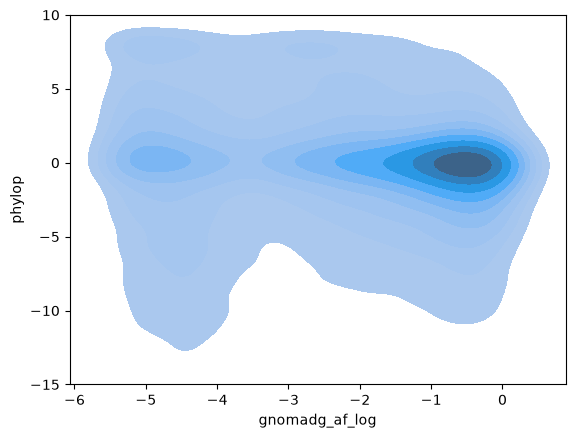

In [ ]:
sns.kdeplot(
    x="gnomadg_af_log", y="phylop", data=plot_data.sample(fraction=0.1), fill=True
)
plt.ylim(-15, 10)

In [ ]:
want_data = (
    df.with_columns(
        **{
            f"{dataset}": pl.col(f"{dataset}_label").is_in(pos_labels).cast(pl.UInt8)
            for dataset, pos_labels in dataset_labels.items()
        }
    )
    .select(*annot_names, *dataset_labels)
    .unpivot(
        on=[*annot_names],
        variable_name="annotation",
        value_name="score",
        index=[*dataset_labels],
    )
    .unpivot(
        on=[*dataset_labels],
        index=["annotation", "score"],
        variable_name="dataset",
        value_name="label",
    )
    .filter(pl.col("score").is_not_null(), pl.col("label").is_not_null())
)

want_data.head()

annotation,score,dataset,label
str,f64,str,u8
"""gnocchi_z""",1.535938,"""gwas""",0
"""gnocchi_z""",4.937684,"""gwas""",0
"""gnocchi_z""",1.509945,"""gwas""",0
"""gnocchi_z""",3.233242,"""gwas""",0
"""gnocchi_z""",3.233242,"""gwas""",0


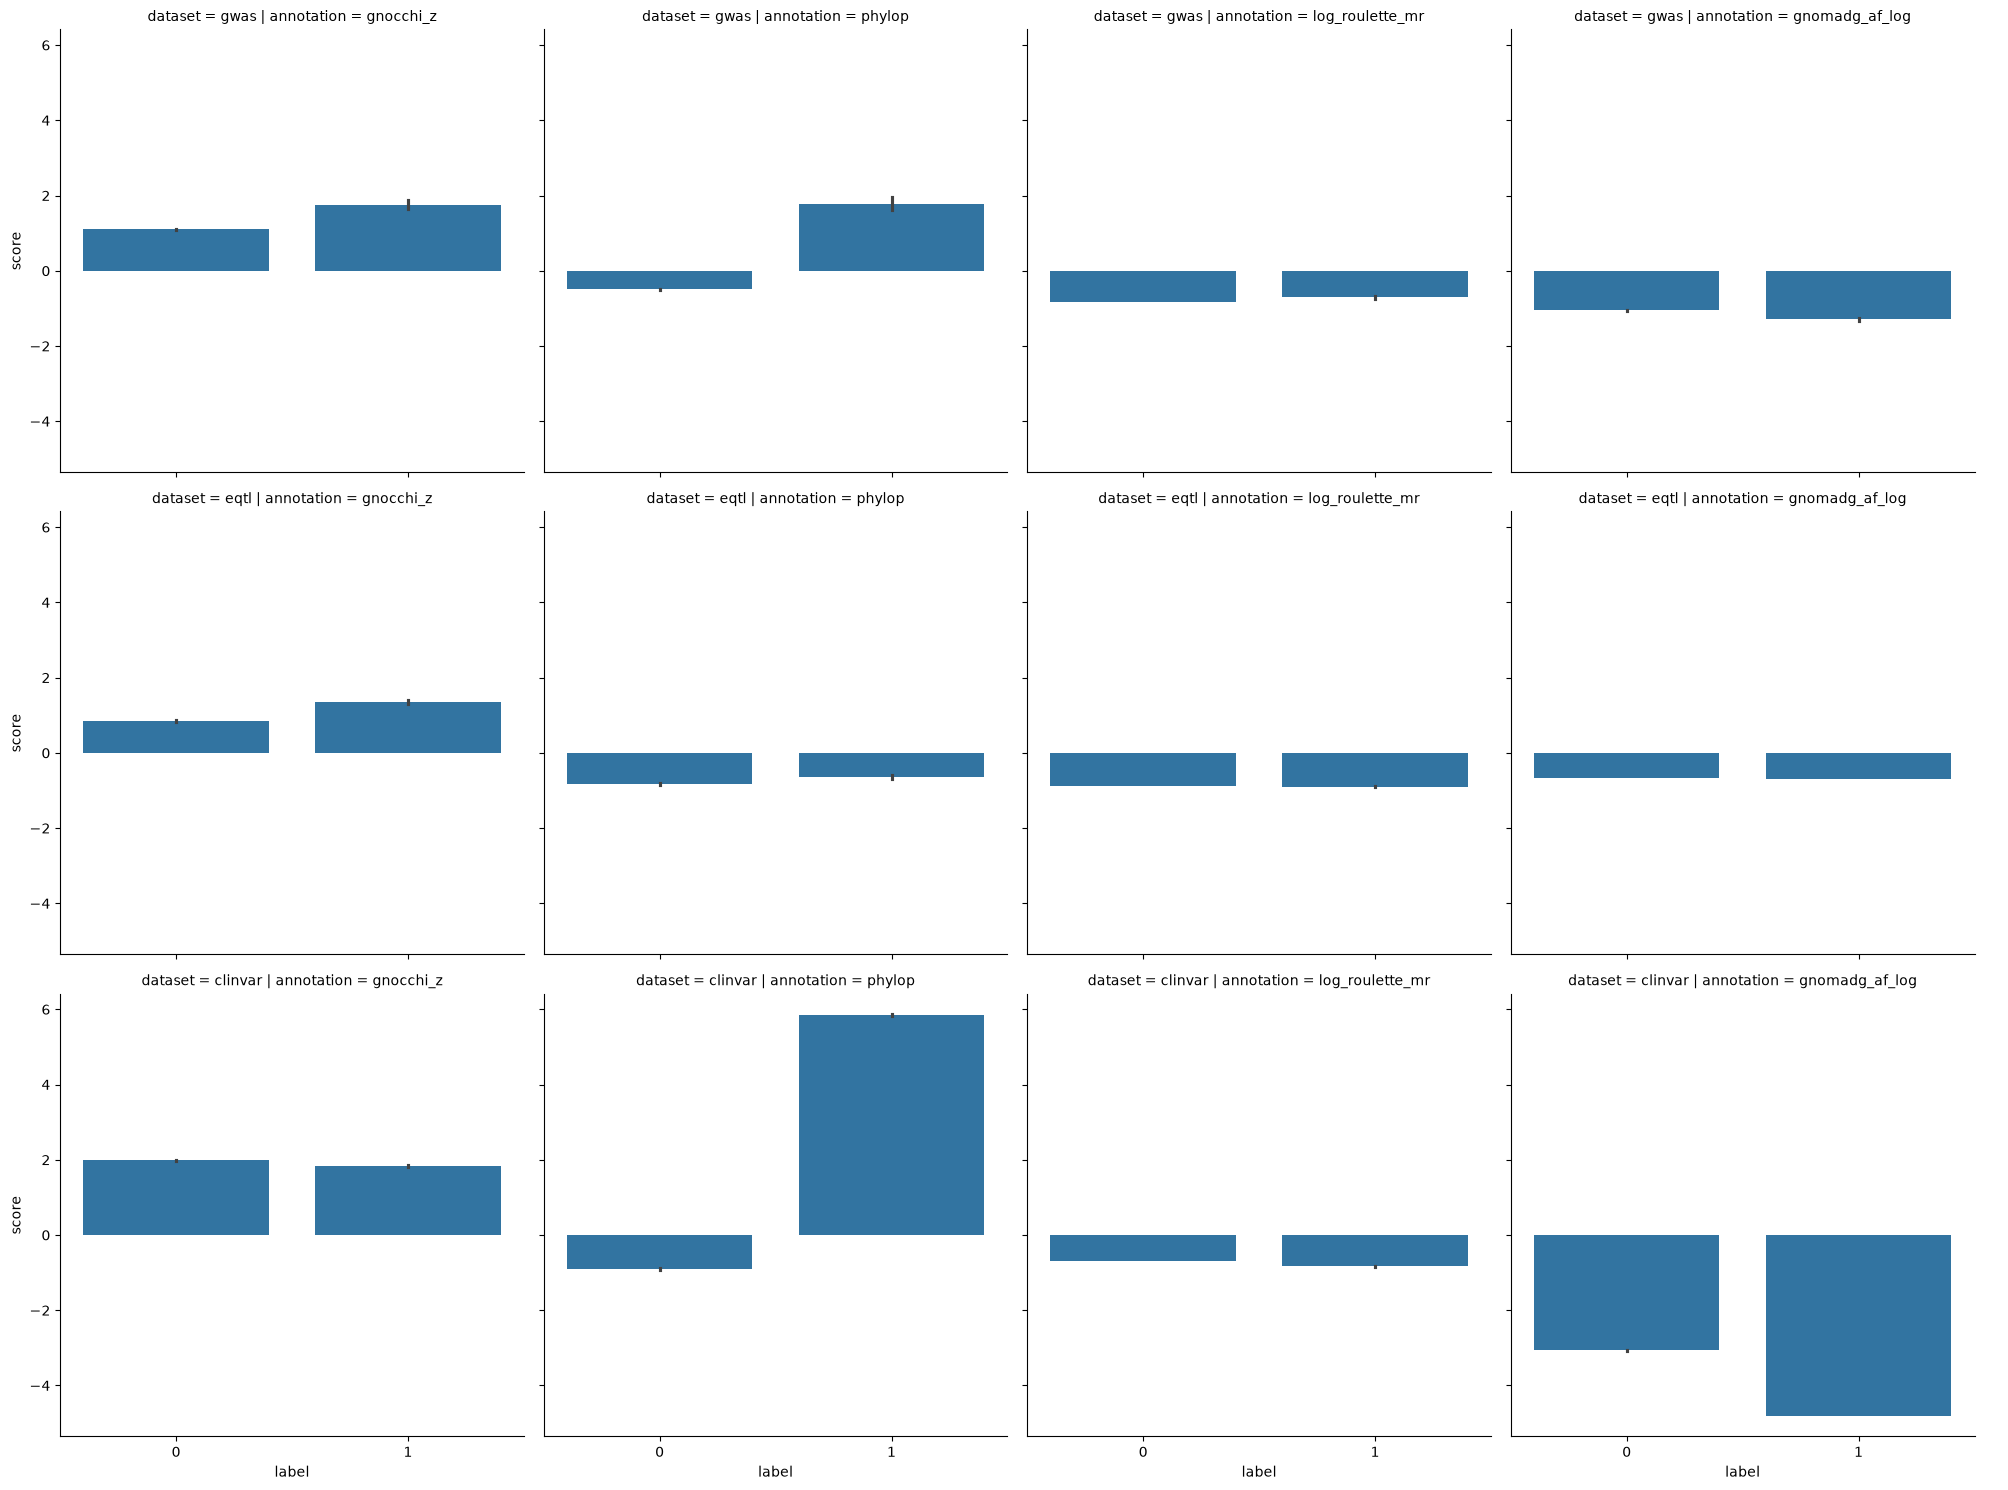

In [ ]:
sns.catplot(
    x="label",
    y="score",
    col="annotation",
    row="dataset",
    kind="bar",
    data=want_data,
)

## Univariate dataset performance

In [45]:
def raw_score_comparison(
    data: pl.DataFrame,
    dataset_labels: dict[str, list[str]] = dataset_labels,
    scores: list[str] = list(annot_names.keys()) + list(model_names.keys()),
    title: str | None = None,
) -> pl.DataFrame:

    want_data = data.with_columns(
        **{
            f"{dataset}": pl.col(f"{dataset}_label").is_in(pos_labels).cast(pl.UInt8)
            for dataset, pos_labels in dataset_labels.items()
        }
    ).filter(pl.all_horizontal(pl.col(*scores).is_not_null()))

    metrics = []
    for dataset in dataset_labels:
        ds_data = want_data.filter(pl.col(dataset).is_not_null())
        y_true = ds_data.get_column(dataset)
        print(f"{dataset}: {y_true.sum()} / {len(y_true)}")

        for score in scores:
            y_pred = ds_data.get_column(score)
            metrics.append(
                {
                    "dataset": dataset,
                    "score": score,
                    "auroc": roc_auc_score(y_true=y_true, y_score=y_pred),
                    "auprc": average_precision_score(y_true=y_true, y_score=y_pred),
                }
            )

    score_rename = {}
    score_rename.update(annot_names)
    score_rename.update(model_names)
    metrics = (
        pl.DataFrame(metrics)
        .with_columns(
            score=pl.col("score").replace(score_rename),
            dataset=pl.col("dataset").replace(dataset_names),
        )
        .unpivot(
            on=["auroc", "auprc"],
            index=["dataset", "score"],
            variable_name="metric",
            value_name="value",
        )
    )

    fg = sns.FacetGrid(data=metrics, col="metric", aspect=1.5, height=5, sharey=False)
    fg.map_dataframe(sns.barplot, x="dataset", hue="score", y="value", palette="muted")
    fg.set_titles("")
    fg.add_legend()

    auroc_ax = fg.axes[0][0]
    auroc_ax.set_ylim(0.4)
    auroc_ax.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    auroc_ax.set_ylabel("AUROC")
    fg.axes[0][1].set_ylabel("AUPRC")

    if title is not None:
        plt.suptitle(title)
    plt.tight_layout()

    # plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
    # plt.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    # plt.ylim(0.4)
    # plt.show()

    # sns.barplot(
    #     x="dataset",
    #     hue="score",
    #     y="auprc",
    #     data=metrics,
    # )

    return metrics

In [46]:
def raw_score_comparison_simple(
    data: pl.DataFrame,
    dataset_labels: dict[str, list[str]] = dataset_labels,
    scores: list[str] = list(annot_names.keys()) + list(model_names.keys()),
    title: str | None = None,
) -> pl.DataFrame:

    want_data = data.with_columns(
        **{
            f"{dataset}": pl.col(f"{dataset}_label").is_in(pos_labels).cast(pl.UInt8)
            for dataset, pos_labels in dataset_labels.items()
        }
    ).filter(pl.all_horizontal(pl.col(*scores).is_not_null()))

    metrics = []
    for dataset in dataset_labels:
        ds_data = want_data.filter(pl.col(dataset).is_not_null())
        y_true = ds_data.get_column(dataset)
        print(f"{dataset}: {y_true.sum()} / {len(y_true)}")

        for score in scores:
            y_pred = ds_data.get_column(score)
            metrics.append(
                {
                    "dataset": dataset,
                    "score": score,
                    "auroc": roc_auc_score(y_true=y_true, y_score=y_pred),
                    "auprc": average_precision_score(y_true=y_true, y_score=y_pred),
                }
            )

    score_rename = {}
    score_rename.update(annot_names)
    score_rename.update(model_names)
    metrics = pl.DataFrame(metrics).with_columns(
        score=pl.col("score").replace(score_rename),
        dataset=pl.col("dataset").replace(dataset_names),
    )
    ax = sns.barplot(
        x="dataset",
        hue="score",
        y="auroc",
        legend=True,
        data=metrics,
    )
    plt.legend(title="Model")

    ax.set_ylim(0.4)
    ax.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    ax.set_ylabel("AUROC")
    sns.despine()

    if title is not None:
        plt.title(title)
    plt.tight_layout()

    return metrics

gwas: 343 / 5070
eqtl: 254 / 1947
clinvar: 1290 / 10650


dataset,score,metric,value
str,str,str,f64
"""GWAS""","""Gnocchi""","""auroc""",0.54153
"""GWAS""","""PhyloP""","""auroc""",0.665764
"""GWAS""","""log(Roulette MR)""","""auroc""",0.548626
"""GWAS""","""log(MAF)""","""auroc""",0.532912
"""GWAS""","""Evo2""","""auroc""",0.641253
"""GWAS""","""NTv3 (100M)""","""auroc""",0.479527
"""GWAS""","""NTv3 (650M)""","""auroc""",0.540094
"""GWAS""","""RiNALMo""","""auroc""",0.502497
…,…,…,…


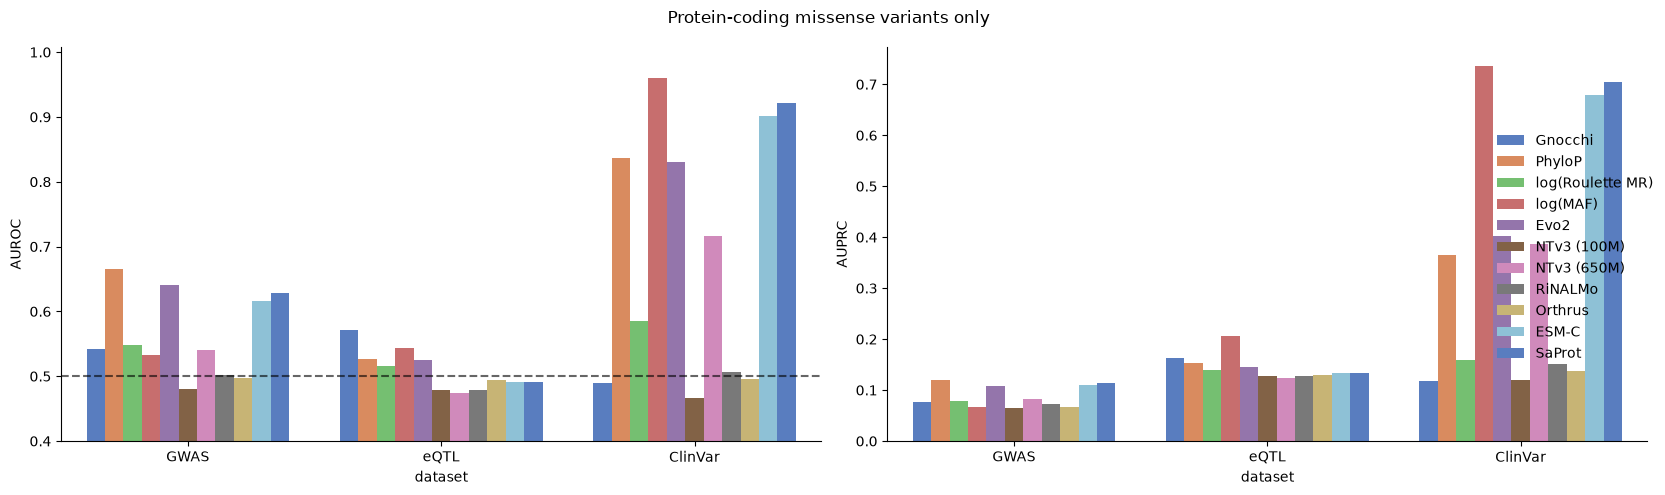

In [47]:
raw_score_comparison(
    df.with_columns(gnomadg_af_log=-pl.col("gnomadg_af_log")),
    title="Protein-coding missense variants only",
)


gwas: 343 / 5086
eqtl: 254 / 1947
clinvar: 4762 / 14243


dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""Gnocchi""",0.541072,0.07572
"""GWAS""","""PhyloP""",0.665621,0.119548
"""GWAS""","""Evo2""",0.6409,0.107028
"""GWAS""","""NTv3 (100M)""",0.479276,0.064375
"""GWAS""","""NTv3 (650M)""",0.539912,0.082719
"""GWAS""","""RiNALMo""",0.502053,0.071767
"""GWAS""","""Orthrus""",0.497727,0.065735
"""GWAS""","""ESM-C""",0.616396,0.110583
…,…,…,…


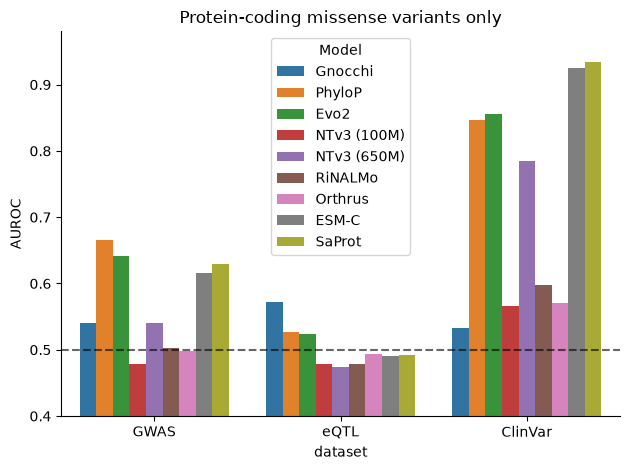

In [48]:
want_scores = [
    x
    for x in list(annot_names.keys()) + list(model_names.keys())
    if x
    not in [
        "log_roulette_mr",
        "gnomadg_af_log",
    ]
]
raw_score_comparison_simple(
    df,
    title="Protein-coding missense variants only",
    scores=want_scores,
)


gwas: 628 / 9844
eqtl: 620 / 3938
clinvar: 8901 / 27778


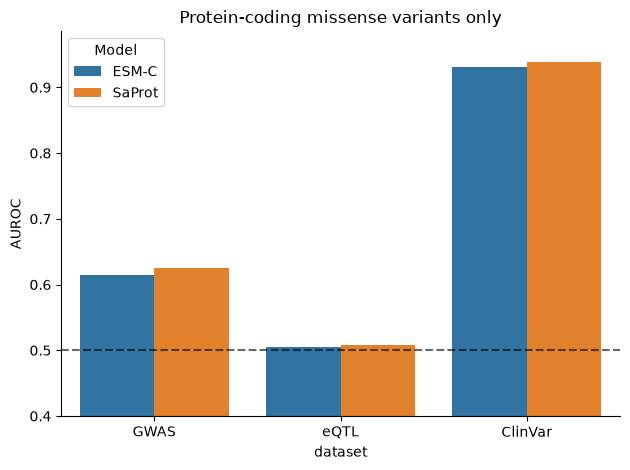

In [51]:
ms_scores = raw_score_comparison_simple(
    df,
    title="Protein-coding missense variants only",
    scores=["esmc_score", "saprot_score"],
)


gwas: 841 / 61716
eqtl: 4332 / 36697
clinvar: 11320 / 73024


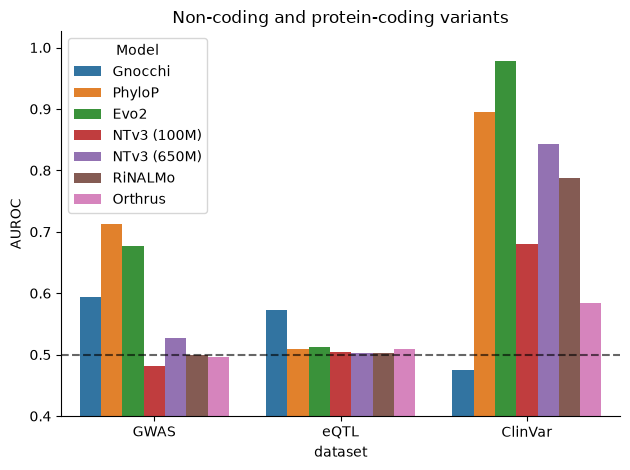

In [52]:
gw_scores = raw_score_comparison_simple(
    df,
    scores=[x for x in want_scores if x not in ["esmc_score", "saprot_score"]],
    title="Non-coding and protein-coding variants",
)

In [53]:
combined_scores = pl.concat((ms_scores, gw_scores))
combined_scores.head()

dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""ESM-C""",0.614645,0.113899
"""GWAS""","""SaProt""",0.625879,0.110628
"""eQTL""","""ESM-C""",0.505598,0.170813
"""eQTL""","""SaProt""",0.508113,0.172092
"""ClinVar""","""ESM-C""",0.930681,0.894633


In [55]:
combined_scores.group_by("dataset").agg(pl.mean("auroc"), pl.mean("auprc"))

dataset,auroc,auprc
str,f64,f64
"""eQTL""",0.513992,0.13543
"""GWAS""",0.581085,0.04649
"""ClinVar""",0.790133,0.613788


## Complementarity

In [56]:
def prepare_labeled_data(
    data: pl.DataFrame,
    feature_cols: list[str],
    label_columns: list[str],
) -> pl.DataFrame:
    """Collapse labels to single binary 0/1 labels."""
    return data.filter(
        pl.all_horizontal(pl.col(feature_cols).is_not_null()),
        pl.any_horizontal(pl.col(label_columns).is_not_null()),
    ).with_columns(
        label=pl.any_horizontal(
            (pl.col(label_columns) == "high_pip").fill_null(False),
            (pl.col(label_columns).str.contains("athogenic")).fill_null(False),
        ).cast(pl.Int8),
    )


def select_biotype_group(
    data: pl.DataFrame,
    biotype: Literal["all", "protein_coding", "lncRNA"],
) -> pl.DataFrame:
    return data if biotype == "all" else data.filter(pl.col("biotype") == biotype)


def cv_eval_models(
    full_data: pl.DataFrame,
    label_cols: list[str],
    models: dict[str, Any],
    cv: StratifiedGroupKFold,
    shared_variants_only: bool = False,
) -> tuple[pl.DataFrame, np.ndarray, dict[str, np.ndarray]]:
    if shared_variants_only:
        all_features = list(
            {feat_name for features, _ in models.values() for feat_name in features}
        )
        full_data = prepare_labeled_data(
            data=full_data,
            feature_cols=all_features,
            label_columns=label_cols,
        )

    predictions = {}
    metrics = []
    for model_name, (features, model) in models.items():
        labeled_data = prepare_labeled_data(
            data=full_data,
            feature_cols=features,
            label_columns=label_cols,
        )

        groups = labeled_data.get_column("variant").to_numpy()
        y = labeled_data.get_column("label").to_numpy()

        prediction = cross_val_predict(
            model,
            labeled_data.select(features).to_numpy(),
            y,
            groups=groups,
            cv=cv,
            method="predict_proba",
            n_jobs=2,
        )[:, 1]
        predictions[model_name] = prediction
        metrics.append(
            {
                "model": model_name,
                "auroc": roc_auc_score(y, prediction),
                "auprc": average_precision_score(y, prediction),
            }
        )
    return pl.DataFrame(metrics), y, predictions


def eval_all_datasets(
    full_data: pl.DataFrame,
    dataset_specs: dict[str, list[str]],
    want_biotypes: list[str],
    model_specs: dict[str, Any],
    n_folds: int = 5,
    shared_variants_only: bool = False,
) -> tuple[pl.DataFrame, dict[str, np.ndarray], dict[str, np.ndarray]]:
    complementarity_cv = StratifiedGroupKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42,
    )

    oof_predictions = {}
    oof_outcomes = {}
    model_metrics = []
    for dataset, label_columns in dataset_specs.items():
        for biotype in want_biotypes:
            data = select_biotype_group(full_data, biotype)
            metrics, _y, _predictions = cv_eval_models(
                full_data=data,
                label_cols=label_columns,
                models=model_specs,
                cv=complementarity_cv,
                shared_variants_only=shared_variants_only,
            )
            key = (dataset, biotype)
            oof_outcomes[key] = _y
            oof_predictions[key] = _predictions
            model_metrics.append(
                metrics.with_columns(dataset=pl.lit(dataset), biotype=pl.lit(biotype))
            )
    model_metrics = pl.concat(model_metrics).sort(
        "dataset", "biotype", "auroc", descending=[False, False, True]
    )
    return model_metrics, oof_predictions, oof_outcomes


In [57]:
dataset_specs = {
    "GWAS": ["ukbb_label", "multisusie_label"],
    "eQTL": ["eqtl_label"],
    "All": ["ukbb_label", "multisusie_label", "eqtl_label"],
    "ClinVar": ["clinvar_label"],
}
analysis_biotypes = ["all", "protein_coding", "lncRNA"]

group_sizes = pl.DataFrame(
    [
        {
            "dataset": _dataset,
            "biotype": _biotype,
            "variants": len(_data),
            "high_pip": _data.get_column("label").sum(),
            "low_pip": len(_data) - _data.get_column("label").sum(),
        }
        for _dataset, _label_columns in dataset_specs.items()
        for _biotype in analysis_biotypes
        for _data in [
            select_biotype_group(
                prepare_labeled_data(df, ["phylop", "gnocchi_z"], _label_columns),
                _biotype,
            )
        ]
    ]
)
group_sizes

dataset,biotype,variants,high_pip,low_pip
str,str,i64,i64,i64
"""GWAS""","""all""",81631,1138,80493
"""GWAS""","""protein_coding""",53510,910,52600
"""GWAS""","""lncRNA""",28121,228,27893
"""eQTL""","""all""",49988,6440,43548
"""eQTL""","""protein_coding""",34597,3864,30733
"""eQTL""","""lncRNA""",15391,2576,12815
"""All""","""all""",114952,7486,107466
"""All""","""protein_coding""",75528,4701,70827
"""All""","""lncRNA""",39424,2785,36639


In [58]:
lr_cv_params = {
    "l1_ratios": (0.0,),
    "scoring": "neg_log_loss",
    "use_legacy_attributes": False,
    "n_jobs": 8,
}

linear_model = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(**lr_cv_params),
)

interaction_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticRegressionCV(**lr_cv_params),
)


def model_to_specs(score_name: str) -> dict[str, Any]:
    shorthand = score_name.replace("_score", "")
    return {
        f"{shorthand}_gnocchi": (
            [score_name, "gnocchi_z"],
            interaction_model,
        ),
        # f"{score_name}_roulette": (
        #     [score_name, "log_roulette_mr"],
        #     interaction_model,
        # ),
        f"{shorthand}_phylop": ([score_name, "phylop"], interaction_model),
        # f"{score_name}_constraint": (
        #     [score_name, "gnocchi_z", "log_roulette_mr"],
        #     interaction_model,
        # ),
        f"{shorthand}_gnocchi_phylop": (
            [score_name, "gnocchi_z", "phylop"],
            interaction_model,
        ),
        # f"{score_name}_all": (
        #     [score_name, "gnocchi_z", "phylop", "log_roulette_mr"],
        #     interaction_model,
        # ),
    }


model_specs = {
    "PhyloP": (["phylop"], linear_model),
    "Gnocchi": (["gnocchi_z"], linear_model),
}

for score_name, pretty_name in model_names.items():
    model_specs.update({pretty_name: ([score_name], linear_model)})
    model_specs.update(model_to_specs(score_name))

    # Underperforms the additive or interaction models across the board
    # "tree": (
    #     ["phylop", "gnocchi_z"],
    #     make_pipeline(
    #         PolynomialFeatures(degree=2, include_bias=False),
    #         StandardScaler(),
    #         GridSearchCV(
    #             estimator=HistGradientBoostingClassifier(),
    #             param_grid={
    #                 "max_depth": [None, 4, 8],
    #                 "max_iter": [50, 100],
    #             },
    #             n_jobs=8,
    #         ),
    #     ),
    # ),

In [59]:
regen = True

In [60]:
# Missense variants only, due to inclusion of ESM-C as a model
if regen:
    ms_perf_metrics, ms_all_preds, ms_all_labels = eval_all_datasets(
        full_data=df,
        dataset_specs=dataset_specs,
        want_biotypes=["all"],
        model_specs=model_specs,
        shared_variants_only=True,
    )

    with open(
        project_dir / "classification" / "missense_preds.pkl",
        "wb",
    ) as fh:
        dump((ms_perf_metrics, ms_all_preds, ms_all_labels), fh)

else:
    with open(
        project_dir / "classification" / "missense_preds.pkl",
        "rb",
    ) as fh:
        ms_perf_metrics, ms_all_preds, ms_all_labels = load(fh)

ms_perf_metrics.head()

model,auroc,auprc,dataset,biotype
str,f64,f64,str,str
"""esmc_gnocchi_phylop""",0.584132,0.125396,"""All""","""all"""
"""nt_100_phylop""",0.579991,0.120656,"""All""","""all"""
"""esmc_phylop""",0.579095,0.12627,"""All""","""all"""
"""rinalmo_phylop""",0.579064,0.1204,"""All""","""all"""
"""rinalmo_gnocchi_phylop""",0.578246,0.120259,"""All""","""all"""


In [61]:
# All variants, excluding ESM-C and SaProt as a model
if regen:
    gw_specs = {}
    for name, spec in model_specs.items():
        if "esm" in name.lower() or "saprot" in name.lower():
            continue
        gw_specs[name] = spec

    gw_perf_metrics, gw_all_preds, gw_all_labels = eval_all_datasets(
        full_data=df,
        dataset_specs=dataset_specs,
        want_biotypes=["all"],
        model_specs=gw_specs,
        shared_variants_only=True,
    )
    with open(
        project_dir / "classification" / "genome_wide_preds.pkl",
        "wb",
    ) as fh:
        dump((gw_perf_metrics, gw_all_preds, gw_all_labels), fh)

else:
    with open(
        project_dir / "classification" / "genome_wide_preds.pkl",
        "rb",
    ) as fh:
        gw_perf_metrics, gw_all_preds, gw_all_labels = load(fh)

gw_perf_metrics.head()

model,auroc,auprc,dataset,biotype
str,f64,f64,str,str
"""orthrus_gnocchi_phylop""",0.57496,0.080025,"""All""","""all"""
"""nt_100_gnocchi_phylop""",0.574319,0.079898,"""All""","""all"""
"""rinalmo_gnocchi_phylop""",0.573395,0.079549,"""All""","""all"""
"""nt_650_gnocchi_phylop""",0.571477,0.079325,"""All""","""all"""
"""evo_gnocchi_phylop""",0.571089,0.080871,"""All""","""all"""


In [62]:
def sample_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> dict[str, list[float]]:
    """Bootstrapped estimates of AUROC and AUPRC"""
    rng = np.random.RandomState(seed=42 + job_idx)

    results = defaultdict(list)
    for i in range(num_bootstraps):
        y_true_sample, y_pred_sample = resample(y_true, y_pred, random_state=rng)
        results["auroc"].append(
            roc_auc_score(y_true=y_true_sample, y_score=y_pred_sample)
        )
        results["auprc"].append(
            average_precision_score(y_true=y_true_sample, y_score=y_pred_sample)
        )

    return results


def sample_metric_deltas(
    y_pred_ref: np.ndarray,
    y_pred_oth: np.ndarray,
    y_true: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> dict[str, list[float]]:
    """Bootstrapped estimates of AUROC delta between two models."""
    rng = np.random.RandomState(seed=42 + job_idx)

    results = defaultdict(list)
    for i in range(num_bootstraps):
        y_ref, y_oth, y_t = resample(y_pred_ref, y_pred_oth, y_true, random_state=rng)

        auroc_ref = roc_auc_score(y_t, y_ref)
        auroc_oth = roc_auc_score(y_t, y_oth)
        results["auroc"].append(auroc_oth - auroc_ref)
        results["auroc_pct"].append(100 * (auroc_oth - auroc_ref) / auroc_ref)

        auprc_ref = average_precision_score(y_t, y_ref)
        auprc_oth = average_precision_score(y_t, y_oth)
        results["auprc"].append(auprc_oth - auprc_ref)
        results["auprc_pct"].append(100 * (auprc_oth - auprc_ref) / auprc_ref)
    return results


def nested_metrics_to_df(
    x: list[dict[str, list[str]]],
    index_items: dict[str, str],
) -> pl.DataFrame:
    flat = defaultdict(list)
    for d in x:
        for k, l in d.items():
            flat[k].extend(l)

    flat.update(index_items)
    return pl.DataFrame(flat)


def run_bootstrap_estimates(
    preds: dict[tuple[str, str], dict[str, np.ndarray]],
    labels: dict[tuple[str, str], np.ndarray],
    comparisons=list[tuple[str, tuple[str]]],
    n_jobs: int = 8,
    num_bootstraps_per_job: int = 100,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    seen = set()
    bootstrapped_metrics = []
    bootstrapped_diffs = []

    with Pool(processes=n_jobs) as p:
        for (dataset, biotype), y_true in labels.items():
            for ref_model, compare_models in comparisons:
                y_ref = preds[(dataset, biotype)][ref_model]

                metric_func = partial(sample_metrics, y_true, y_ref)
                bootstrapped_metrics.append(
                    nested_metrics_to_df(
                        x=p.map(metric_func, range(n_jobs)),
                        index_items={"model": ref_model, "dataset": dataset},
                    )
                )

                for compare_model in compare_models:
                    y_oth = preds[(dataset, biotype)][compare_model]

                    if (compare_model, dataset) not in seen:
                        metric_func = partial(sample_metrics, y_true, y_oth)
                        bootstrapped_metrics.append(
                            nested_metrics_to_df(
                                x=p.map(metric_func, range(n_jobs)),
                                index_items={
                                    "model": compare_model,
                                    "dataset": dataset,
                                },
                            )
                        )
                        seen.add((compare_model, dataset))

                    metric_func = partial(sample_metric_deltas, y_ref, y_oth, y_true)
                    bootstrapped_diffs.append(
                        nested_metrics_to_df(
                            x=p.map(metric_func, range(n_jobs)),
                            index_items={
                                "ref": ref_model,
                                "compare": compare_model,
                                "dataset": dataset,
                            },
                        )
                    )
    return pl.concat(bootstrapped_metrics), pl.concat(bootstrapped_diffs)

In [63]:
def make_comparison_lists(
    want_references: list[str],
) -> list[tuple]:
    ret = []
    pretty_to_score = {v: k for k, v in model_names.items()}

    for ref in want_references:
        shorthand = pretty_to_score[ref].replace("_score", "")
        ret.append(
            (
                ref,
                (
                    f"{shorthand}_phylop",
                    f"{shorthand}_gnocchi",
                    f"{shorthand}_gnocchi_phylop",
                ),
            )
        )
    return ret


ms_delta_comparisons = make_comparison_lists(want_references=list(model_names.values()))
gw_delta_comparisons = make_comparison_lists(
    want_references=[x for x in model_names.values() if x not in ["ESM-C", "SaProt"]],
)

In [64]:
if regen:
    ms_bootstrap_metrics, ms_bootstrap_diffs = run_bootstrap_estimates(
        preds=ms_all_preds,
        labels=ms_all_labels,
        comparisons=ms_delta_comparisons,
    )
    with open(
        project_dir / "classification" / "missense_bootstraps.pkl",
        "wb",
    ) as fh:
        dump((ms_bootstrap_metrics, ms_bootstrap_diffs), fh)

else:
    with open(
        project_dir / "classification" / "missense_bootstraps.pkl",
        "rb",
    ) as fh:
        ms_bootstrap_metrics, ms_bootstrap_diffs = load(fh)

ms_bootstrap_metrics.head()

auroc,auprc,model,dataset
f64,f64,str,str
0.629354,0.097769,"""Evo2""","""GWAS"""
0.646195,0.119853,"""Evo2""","""GWAS"""
0.651373,0.121174,"""Evo2""","""GWAS"""
0.642876,0.12229,"""Evo2""","""GWAS"""
0.634862,0.116967,"""Evo2""","""GWAS"""


In [65]:
if regen:
    gw_bootstrap_metrics, gw_bootstrap_diffs = run_bootstrap_estimates(
        preds=gw_all_preds,
        labels=gw_all_labels,
        comparisons=gw_delta_comparisons,
    )
    with open(
        project_dir / "classification" / "genome_wide_bootstraps.pkl",
        "wb",
    ) as fh:
        dump((gw_bootstrap_metrics, gw_bootstrap_diffs), fh)

else:
    with open(
        project_dir / "classification" / "genome_wide_bootstraps.pkl",
        "rb",
    ) as fh:
        gw_bootstrap_metrics, gw_bootstrap_diffs = load(fh)

gw_bootstrap_metrics.head()

In [ ]:
def feature_list_to_sort_key(
    features: list[str],
    feature_order: list[str],
) -> int:
    return sum([2 ** feature_order.index(x) for x in features])


def plot_feature_comparison(
    data: pl.DataFrame,
    ax: plt.Axes,
    ax_sets: plt.Axes,
    feature_order: list[str],
    title: str | None = None,
):
    """Plot performance bars and corresponding UpSet-style feature matrix."""
    # Restrict to comparisons where all features are in the desired feature set
    specs_to_features = {k: v[0] for k, v in model_specs.items()}
    data = (
        data.with_columns(
            feature_set=pl.col("compare").replace_strict(
                specs_to_features, return_dtype=pl.List
            ),
        )
        .filter(
            pl.col("feature_set").list.set_difference(feature_order).list.len() == 0,
        )
        .drop("feature_set")
    )

    names_and_features = sorted(
        [(name, model_specs[name][0]) for name in data.get_column("compare").unique()],
        key=lambda x: feature_list_to_sort_key(x[1], feature_order),
    )
    names, feature_sets = zip(*names_and_features)

    # Performance
    sns.barplot(
        data=data,
        x="compare",
        y="auroc",
        order=names,
        estimator=np.mean,
        errorbar=("pi", 95),
        ax=ax,
    )

    ax2 = ax.twinx()
    sns.barplot(
        data=data,
        x="compare",
        y="auroc_pct",
        order=names,
        estimator=np.mean,
        errorbar=("pi", 95),
        ax=ax2,
    )

    ax.set_title(title or "")
    ax.set_xlabel("")
    ax.axhline(0, color="0.5", lw=0.75)

    # Feature matrix
    for i, feature_set in enumerate(feature_sets):
        included = set(feature_set)

        for j, feature in enumerate(feature_order):
            ax_sets.scatter(
                i,
                j,
                s=45,
                facecolor="black" if feature in included else "white",
                edgecolor="black",
            )
    ax.set_xlim(-0.5, len(names) - 0.5)
    ax_sets.set_xlim(-0.5, len(names) - 0.5)

    ax_sets.set(
        ylim=(-0.5, len(feature_order) - 0.5),
        xticks=[],
        yticks=range(len(feature_order)),
    )
    ax_sets.invert_yaxis()
    ax_sets.tick_params(axis="y", length=0)

    sns.despine(ax=ax)
    sns.despine(ax=ax2, right=False)
    sns.despine(ax=ax_sets, left=True, bottom=True)

    return ax2

In [ ]:
def diffs_upset_plot(
    bootstrap_diffs: pl.DataFrame,
    dataset: str,
    feature_order: list[str] | None = ["phylop", "gnocchi_z"],
    want_refs: list[str] | None = None,
    plot_col: str = "auroc",
):
    plot_data = bootstrap_diffs.filter(pl.col("dataset") == dataset)
    if want_refs is None:
        want_refs = plot_data["ref"].unique().sort().to_list()

    # Determine global feature ordering
    all_names = plot_data["compare"].unique()
    if feature_order is None:
        feature_counts = Counter(f for name in all_names for f in model_specs[name][0])
        feature_order = [
            f for f, _ in feature_counts.most_common() if f not in model_names
        ]

    model_to_score_name = {v: k for k, v in model_names.items()}
    model_to_score_name["Evo"] = "evo_score"

    fig, axs = plt.subplots(
        2,
        len(want_refs),
        figsize=(4 * len(want_refs), 4),
        sharex="col",
        gridspec_kw={
            "height_ratios": [4, 1],
            "hspace": 0.05,
            "wspace": 0.5,
        },
        squeeze=False,
    )

    twin_axes = []
    for i, ref in enumerate(want_refs):
        if ref != "PhyloP":
            this_feature_order = [model_to_score_name[ref]] + feature_order
        else:
            this_feature_order = ["phylop"] + [
                x for x in feature_order if x != "phylop"
            ]
        twin_ax = plot_feature_comparison(
            plot_data.filter(pl.col("ref") == ref),
            ax=axs[0, i],
            ax_sets=axs[1, i],
            feature_order=this_feature_order,
            title=f"ref = {ref}",
        )
        axs[0, i].set_ylabel("")
        twin_ax.set_ylabel("")
        axs[1, i].set_yticklabels([pretty_names.get(f, "") for f in this_feature_order])
        twin_axes.append(twin_ax)

    label = ""
    if plot_col == "auroc":
        label = r"$\Delta$ AUROC"
        label_pct = "% AUROC change"
    elif plot_col == "auroc_pct":
        label = "% AUROC change"
    elif plot_col == "auprc":
        label = r"$\Delta$ AUPRC"
    elif plot_col == "auprc_pct":
        label = "% AUPRC change"

    axs[0, 0].set_ylabel(label)
    twin_axes[-1].set_ylabel(label_pct)

    # if i == 0:
    #     axs[1, i].set_yticklabels([pretty_names[f] for f in feature_order])
    # else:
    #     axs[1, i].set_yticklabels([])
    plt.tight_layout()
    plt.suptitle(f"Dataset = {dataset}")

In [ ]:
def diffs_upset_plot_by_modality(
    bootstrap_diffs: pl.DataFrame,
    dataset: str,
    feature_order: list[str] | None = ["phylop", "gnocchi_z"],
    want_refs: list[str] | None = None,
    plot_col: str = "auroc",
):
    plot_data = bootstrap_diffs.filter(pl.col("dataset") == dataset)
    if want_refs is None:
        want_refs = plot_data["ref"].unique().sort().to_list()

    # Determine global feature ordering
    all_names = plot_data["compare"].unique()
    if feature_order is None:
        feature_counts = Counter(f for name in all_names for f in model_specs[name][0])
        feature_order = [
            f for f, _ in feature_counts.most_common() if f not in model_names
        ]

    model_to_score_name = {v: k for k, v in model_names.items()}
    model_to_score_name["Evo"] = "evo_score"

    model_modalities = defaultdict(list)
    for ref in want_refs:
        model_modalities[model_to_modality[ref]].append(ref)

    for modality, models in model_modalities.items():
        if len(models) != 2:
            raise ValueError(
                f"expected exactly 2 models per modality, got: {modality} = {len(models)}"
            )

    _, axs = plt.subplots(
        5,
        len(model_modalities),
        figsize=(4 * len(model_modalities), 8),
        # sharex="col",
        sharex=False,
        gridspec_kw={
            "height_ratios": [4, 1, 0.01, 4, 1],
            "hspace": 0.15,
            "wspace": 0.5,
        },
        squeeze=False,
    )

    # Empty spacer row
    for ax in axs[2]:
        ax.axis("off")

    twin_axes = []
    j = 0
    for modality in ["DNA", "RNA", "Protein"]:
        if modality not in model_modalities:
            continue
        models = model_modalities[modality]

        for i, ref in enumerate(models):
            if ref != "PhyloP":
                this_feature_order = [model_to_score_name[ref]] + feature_order
            else:
                this_feature_order = ["phylop"] + [
                    x for x in feature_order if x != "phylop"
                ]

            if i == 0:
                bar_ax = axs[0, j]
                set_ax = axs[1, j]
            else:
                bar_ax = axs[3, j]
                set_ax = axs[4, j]

            title = f"{modality} models" if i == 0 else ""
            twin_ax = plot_feature_comparison(
                plot_data.filter(pl.col("ref") == ref),
                ax=bar_ax,
                ax_sets=set_ax,
                feature_order=this_feature_order,
                title=title,
            )
            bar_ax.set_xticklabels([])
            bar_ax.set_xticks([])
            bar_ax.set_ylabel("")
            twin_ax.set_ylabel("")
            set_ax.set_yticklabels(
                [pretty_names.get(f, "") for f in this_feature_order]
            )
            twin_axes.append(twin_ax)

        j += 1

    label = ""
    if plot_col == "auroc":
        label = r"$\Delta$ AUROC"
        label_pct = "% AUROC change"
    elif plot_col == "auroc_pct":
        label = "% AUROC change"
    elif plot_col == "auprc":
        label = r"$\Delta$ AUPRC"
    elif plot_col == "auprc_pct":
        label = "% AUPRC change"

    axs[0, 0].set_ylabel(label)
    axs[3, 0].set_ylabel(label)
    twin_axes[-1].set_ylabel(label_pct)
    twin_axes[-2].set_ylabel(label_pct)
    # if i == 0:
    #     axs[1, i].set_yticklabels([pretty_names[f] for f in feature_order])
    # else:
    #     axs[1, i].set_yticklabels([])
    plt.tight_layout()
    plt.suptitle(f"Dataset = {dataset}")

### Missense-only feature comparisons

/tmp/ipykernel_user/cell.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


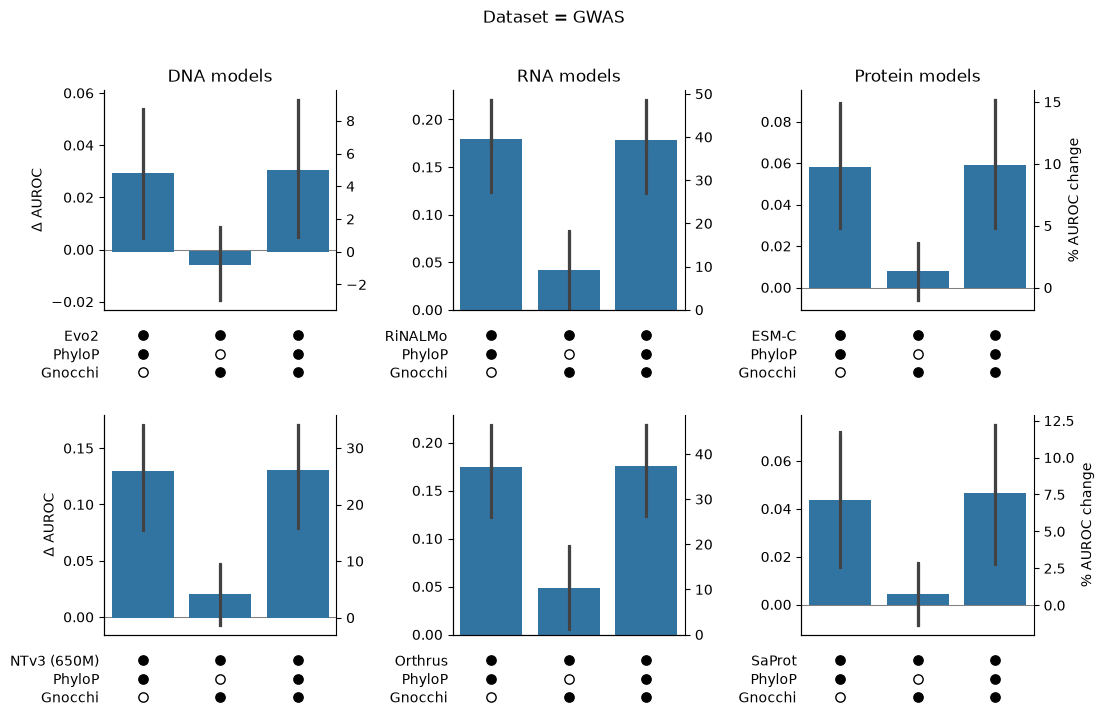

In [ ]:
diffs_upset_plot_by_modality(
    ms_bootstrap_diffs,
    "GWAS",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
)

/tmp/ipykernel_user/cell.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


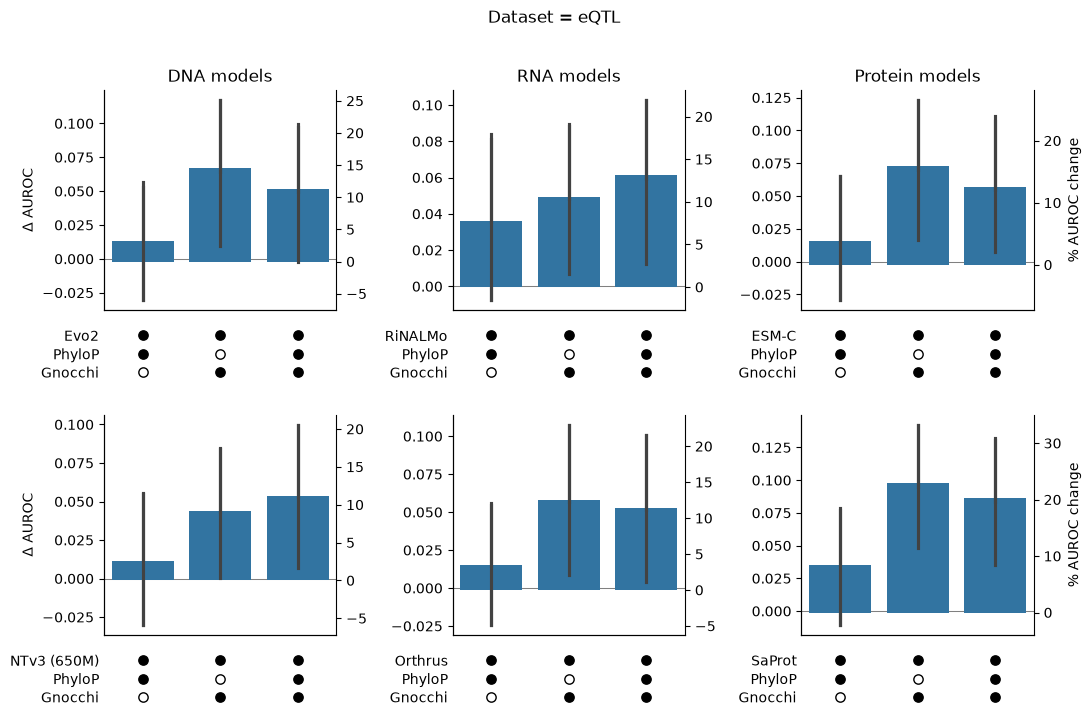

In [150]:
diffs_upset_plot_by_modality(
    ms_bootstrap_diffs,
    "eQTL",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
)

/tmp/ipykernel_user/cell.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


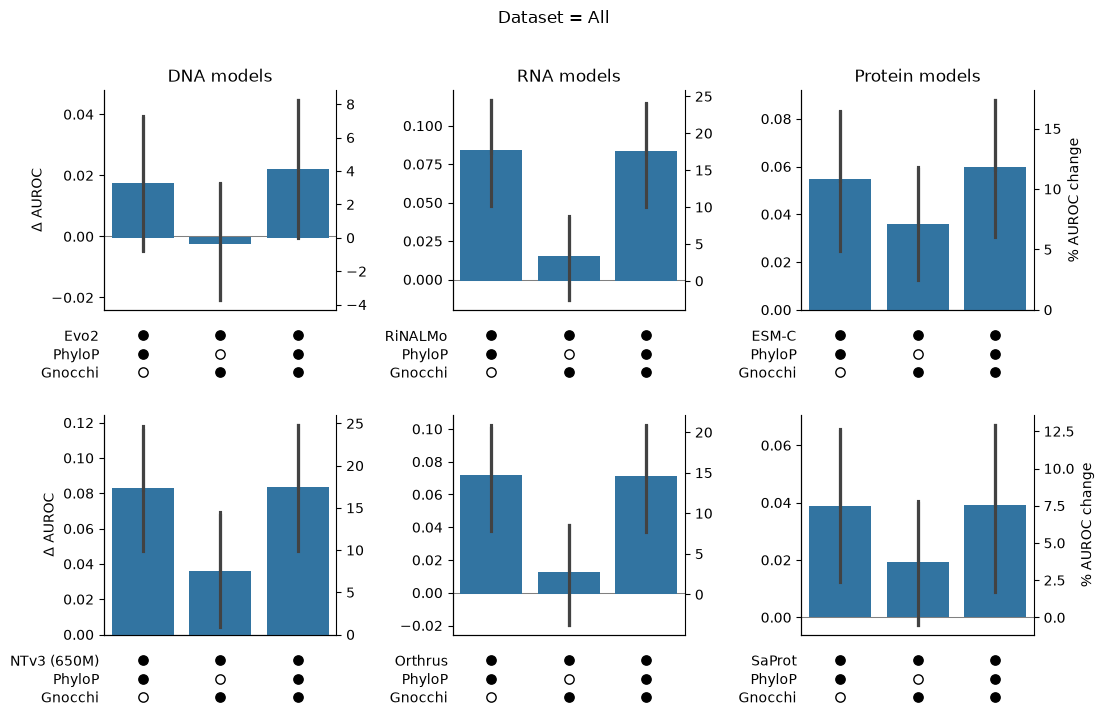

In [174]:
diffs_upset_plot_by_modality(
    ms_bootstrap_diffs,
    "All",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
)

/tmp/ipykernel_user/cell.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


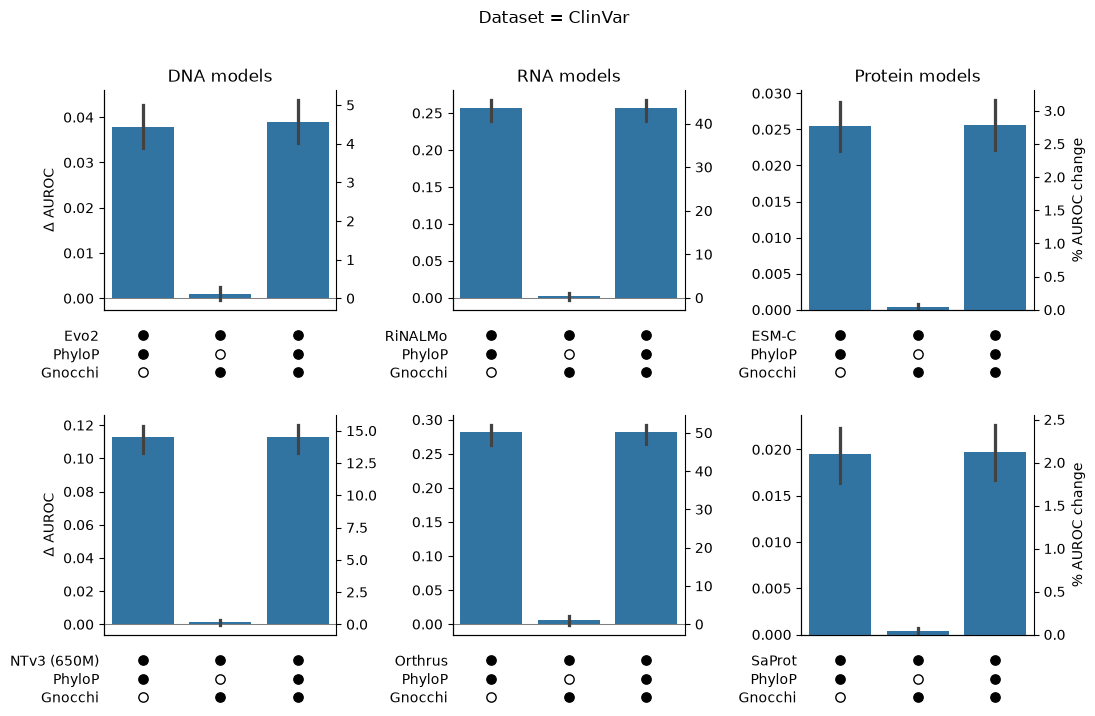

In [ ]:
diffs_upset_plot_by_modality(
    ms_bootstrap_diffs,
    "ClinVar",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
)

### Genome-wide feature comparisons

/tmp/ipykernel_user/cell.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


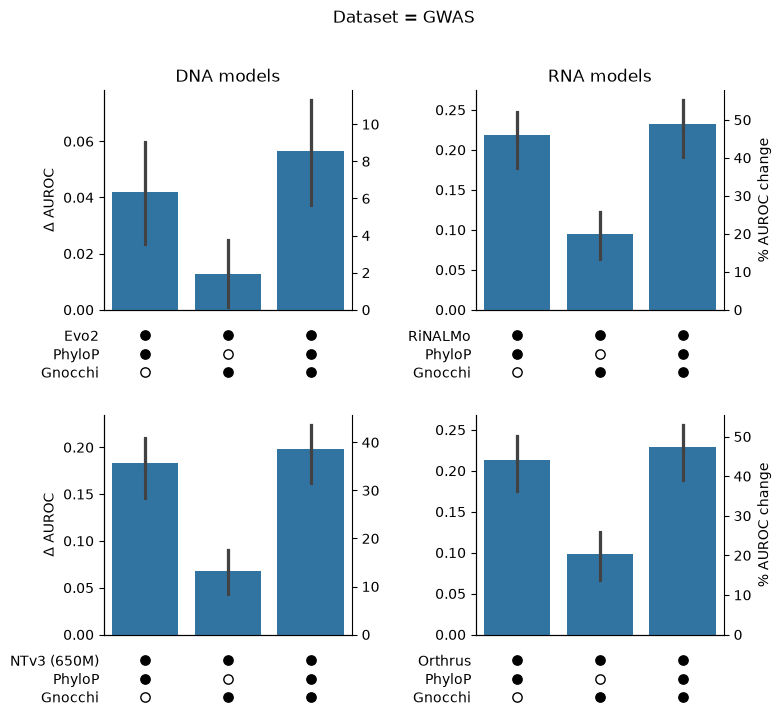

In [152]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "GWAS",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

/tmp/ipykernel_user/cell.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


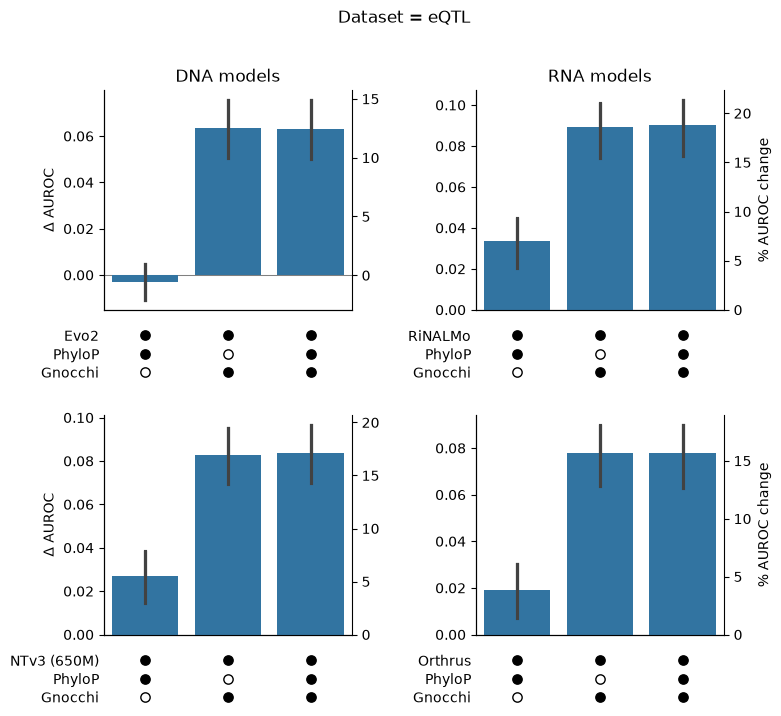

In [153]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "eQTL",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

/tmp/ipykernel_user/cell.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


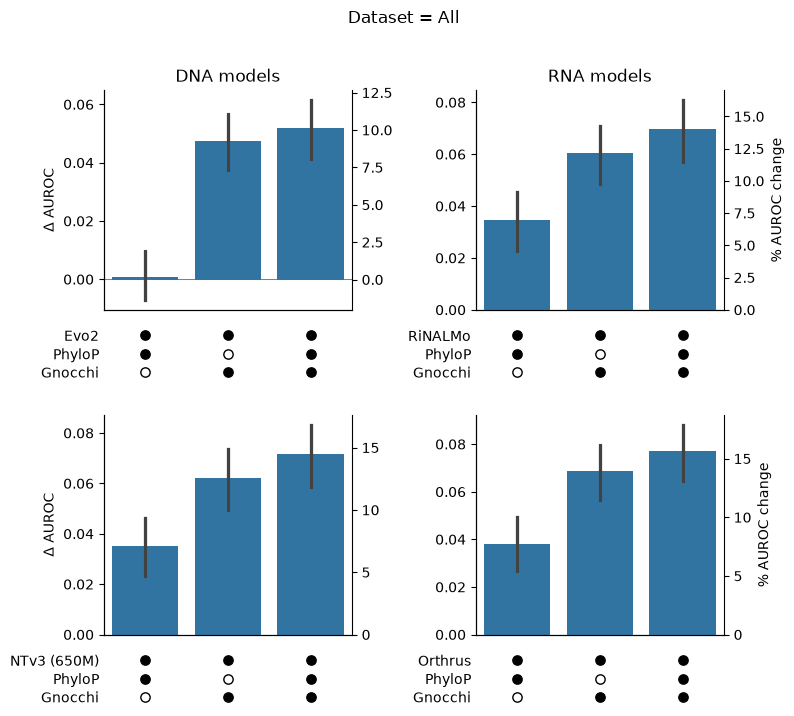

In [154]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "All",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

/tmp/ipykernel_user/cell.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


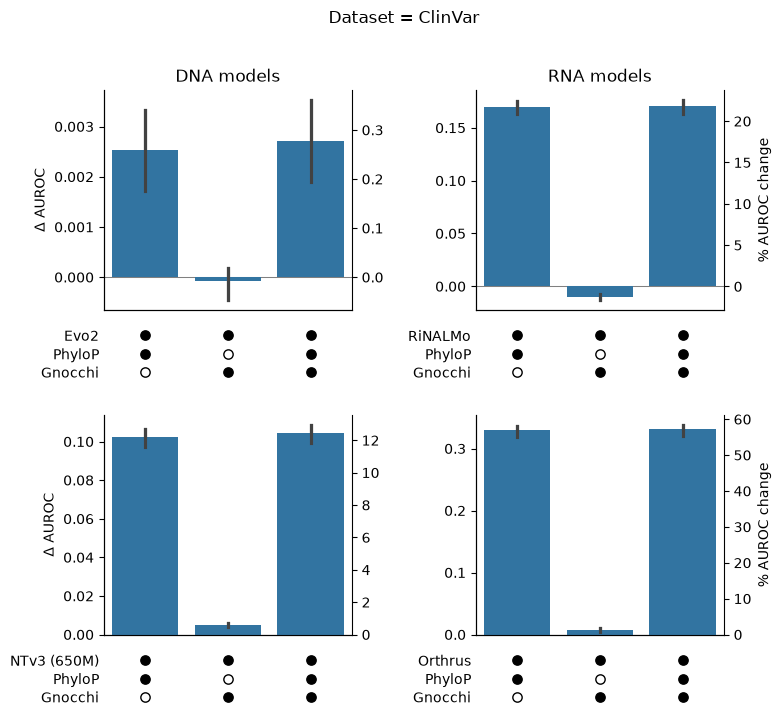

In [155]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "ClinVar",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

### Old plots

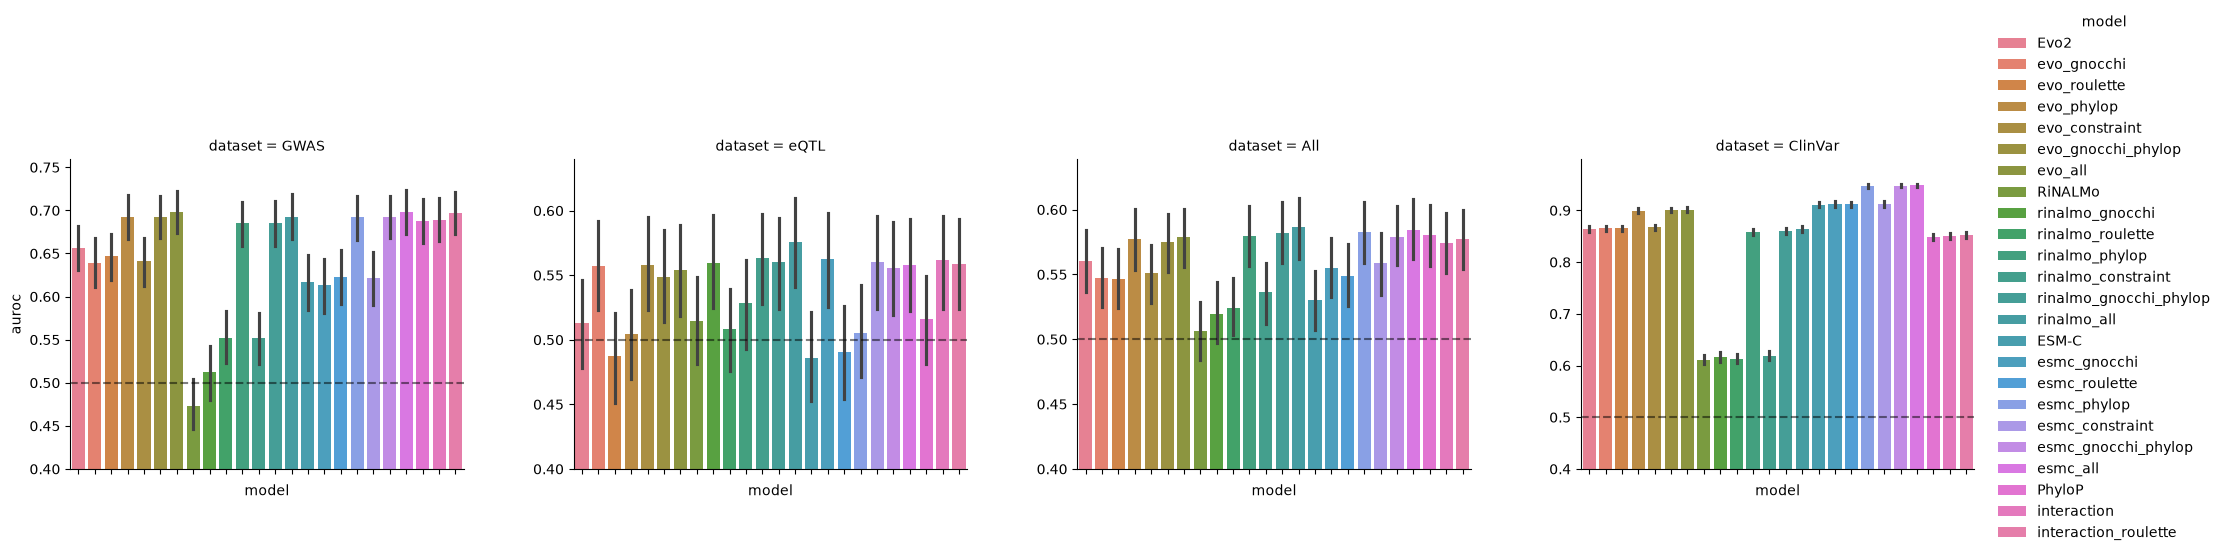

In [ ]:
fg = sns.catplot(
    x="model",
    y="auroc",
    hue="model",
    col="dataset",
    sharey=False,
    kind="bar",
    errorbar=("pi", 95),
    data=ms_bootstrap_metrics,
    legend=True,
)
fg.set_xticklabels([])
for row in fg.axes:
    for ax in row:
        ax.set_ylim(0.4)
        ax.axhline(0.5, linestyle="--", alpha=0.5, color="black")

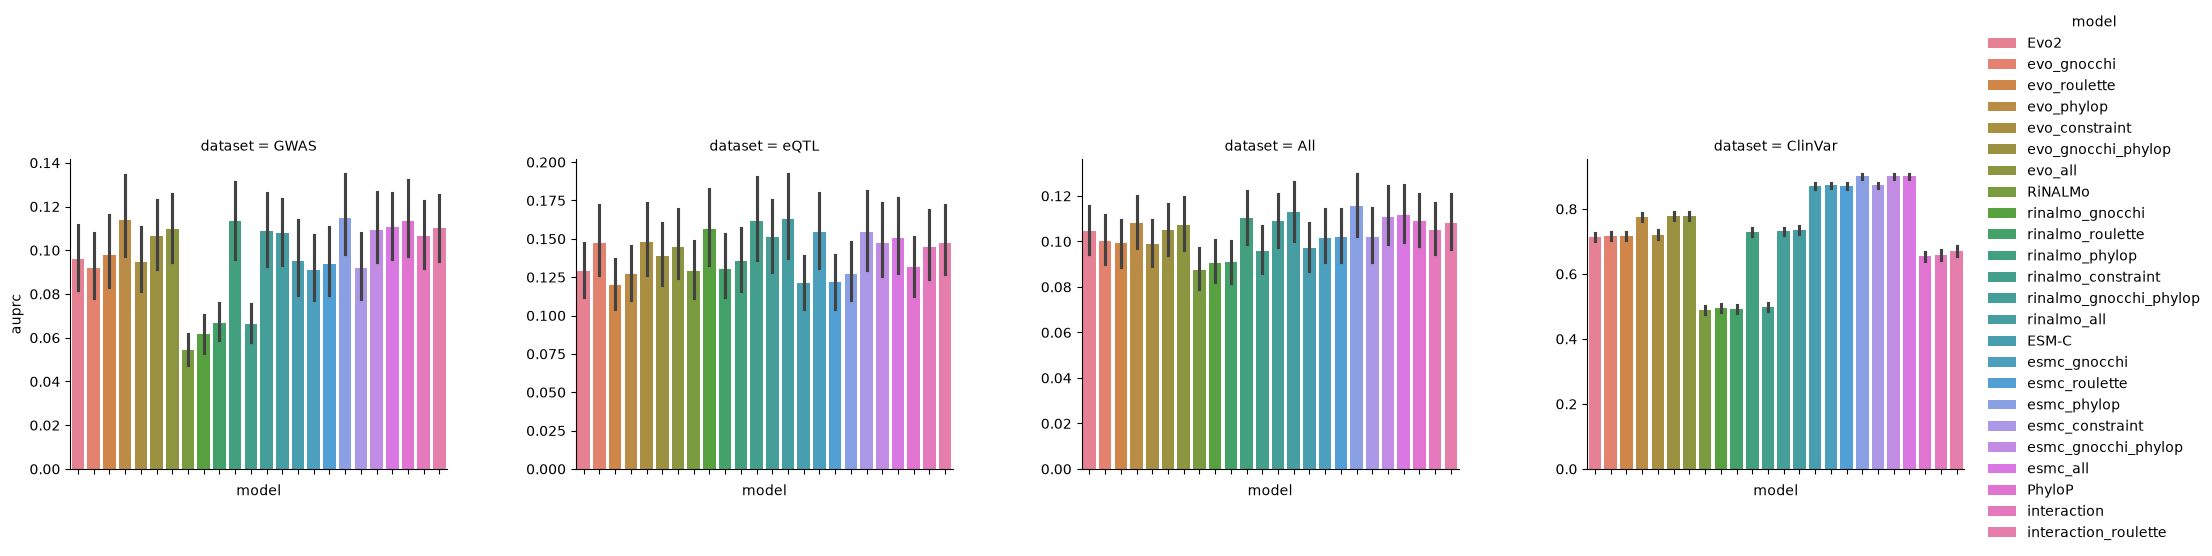

In [ ]:
fg = sns.catplot(
    x="model",
    y="auprc",
    hue="model",
    col="dataset",
    sharey=False,
    kind="bar",
    errorbar=("pi", 95),
    data=ms_bootstrap_metrics,
    legend=True,
)
fg.set_xticklabels([])

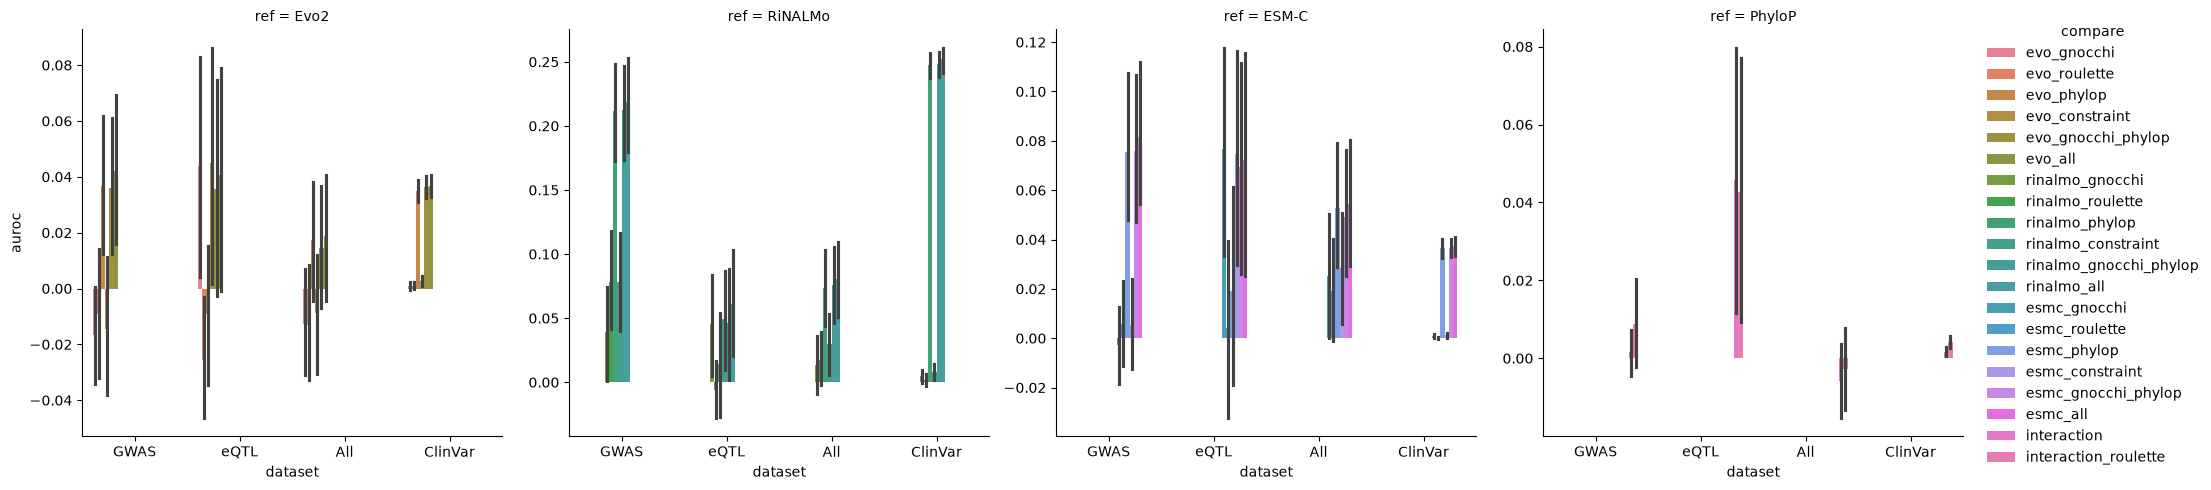

In [ ]:
fg = sns.catplot(
    col="ref",
    x="dataset",
    hue="compare",
    y="auroc",
    sharey=False,
    sharex=False,
    kind="bar",
    errorbar=("pi", 95),
    data=ms_bootstrap_diffs,
    legend=True,
)
# fg.set_xticklabels([])

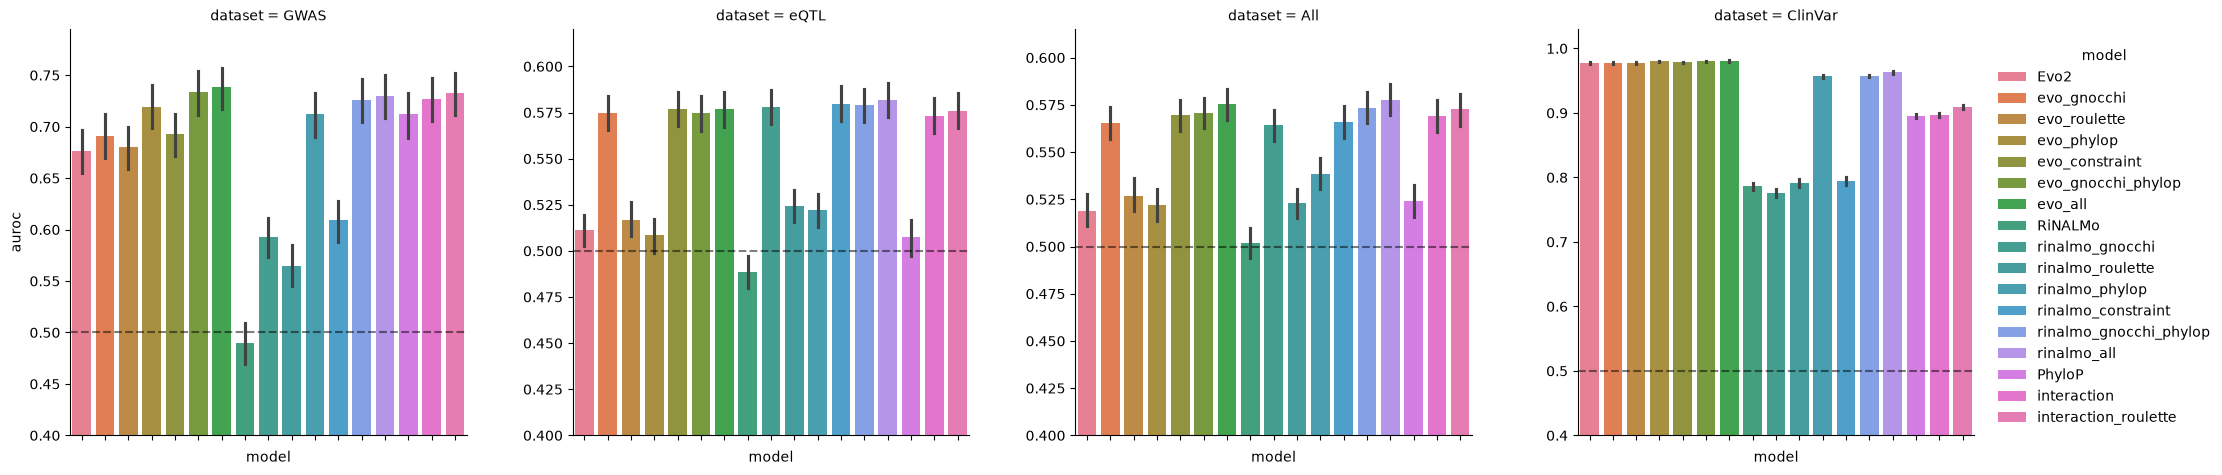

In [ ]:
fg = sns.catplot(
    x="model",
    y="auroc",
    hue="model",
    col="dataset",
    sharey=False,
    kind="bar",
    errorbar=("pi", 95),
    data=gw_bootstrap_metrics,
    legend=True,
)
fg.set_xticklabels([])
for row in fg.axes:
    for ax in row:
        ax.set_ylim(0.4)
        ax.axhline(0.5, linestyle="--", alpha=0.5, color="black")

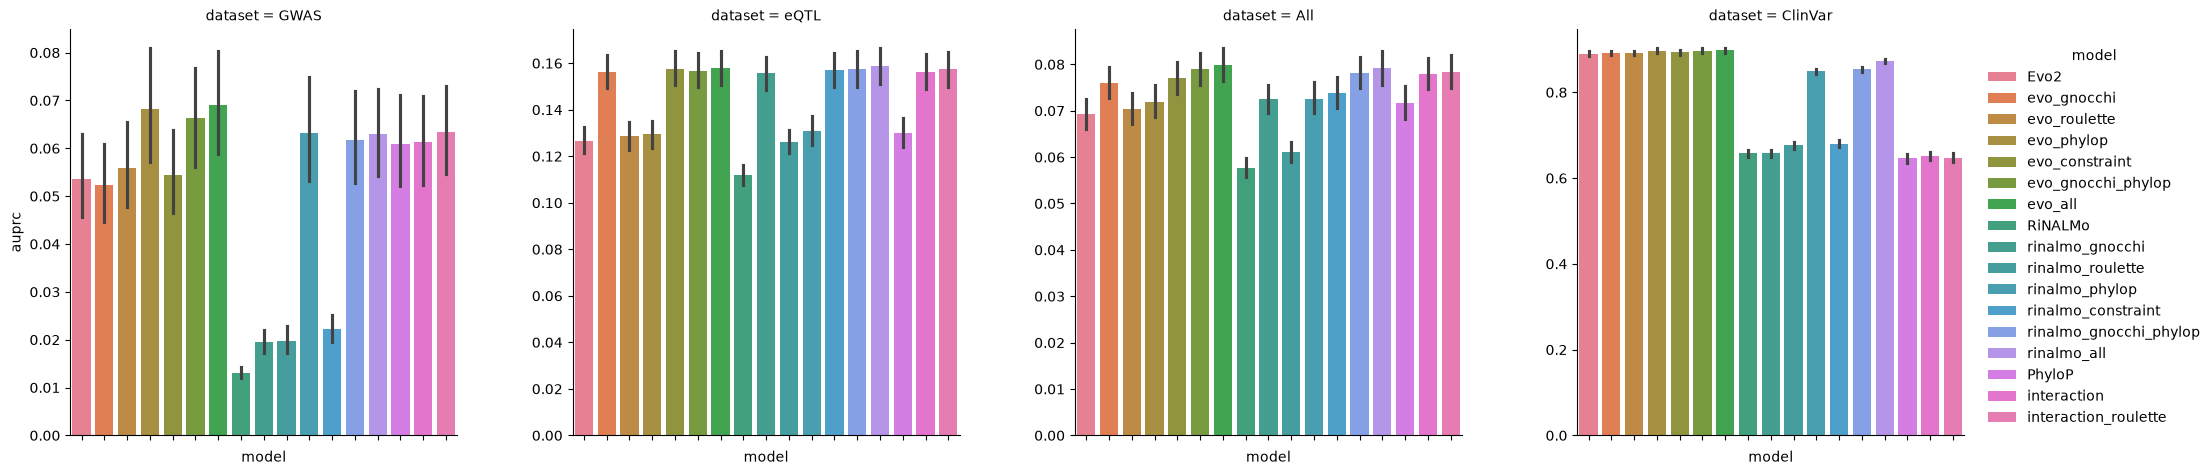

In [ ]:
fg = sns.catplot(
    x="model",
    y="auprc",
    hue="model",
    col="dataset",
    sharey=False,
    kind="bar",
    errorbar=("pi", 95),
    data=gw_bootstrap_metrics,
    legend=True,
)
fg.set_xticklabels([])

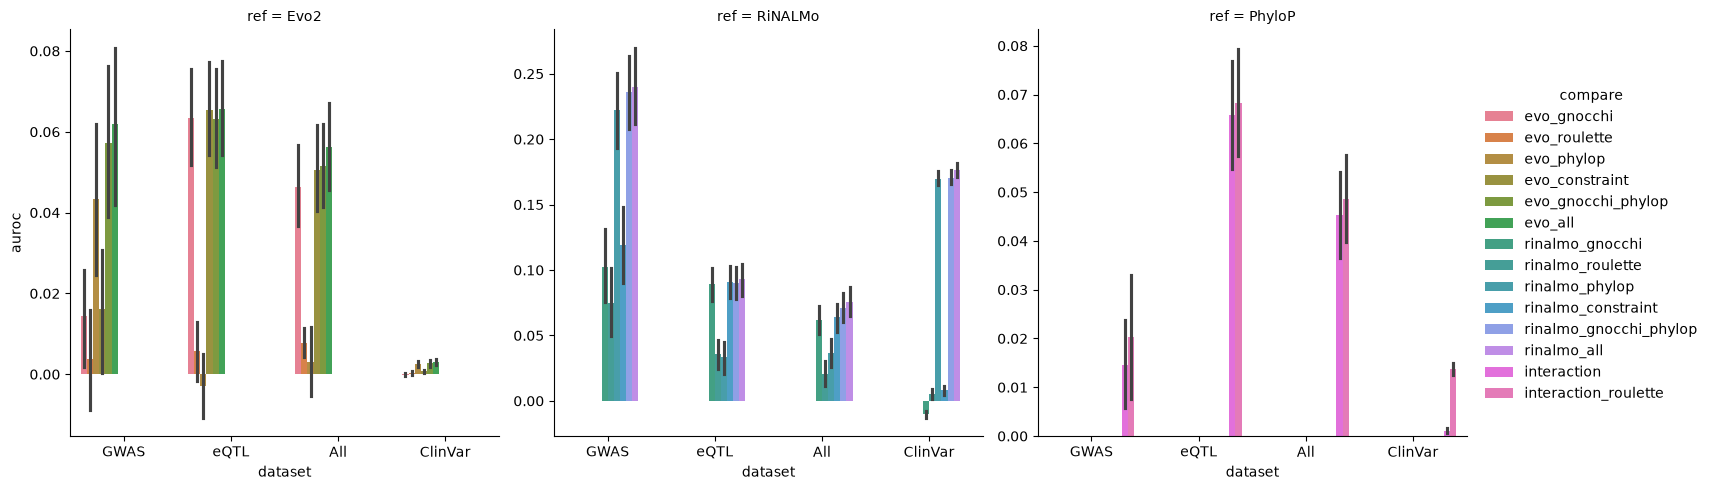

In [ ]:
fg = sns.catplot(
    col="ref",
    x="dataset",
    hue="compare",
    y="auroc",
    sharey=False,
    sharex=False,
    kind="bar",
    errorbar=("pi", 95),
    data=gw_bootstrap_diffs,
    legend=True,
)
# fg.set_xticklabels([])

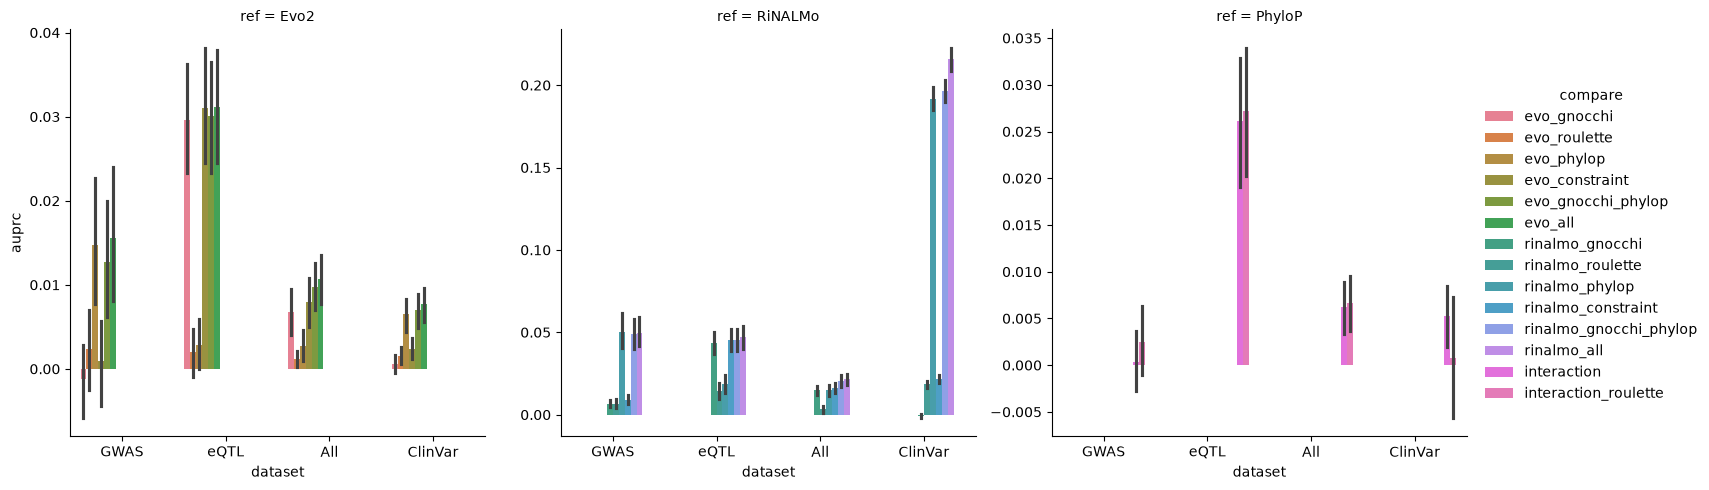

In [ ]:
fg = sns.catplot(
    col="ref",
    x="dataset",
    hue="compare",
    y="auprc",
    sharey=False,
    sharex=False,
    kind="bar",
    errorbar=("pi", 95),
    data=gw_bootstrap_diffs,
    legend=True,
)
# fg.set_xticklabels([])